# Homework #1 (Due 09/02/2026, 11:59pm)

**ELEC70122: ML for Safety Critical Decision-Making**<br>
**Instructor: Sonali Parbhoo**<br>
**Fall 2026**

**Name:**


### Instructions:

**Submission Format:** Use this notebook as a template to complete your homework. Please intersperse text blocks (using Markdown cells) amongst `python` code and results -- format your submission for maximum readability. Your assignments will be graded for correctness as well as clarity of exposition and presentation -- a “right” answer by itself without an explanation or is presented with a difficult to follow format will receive no credit.

**Code Check:** Before submitting, you must do a "Restart and Run All" under "Kernel" in the Jupyter or colab menu. ***Portions of your submission that contains syntactic or run-time errors will not be graded***.

**Libraries and packages:** Unless a problems specifically asks you to implement from scratch, you are welcomed to use any `python` library package in the standard Anaconda distribution.

In [1]:
### Import basic libraries
import numpy as np
import pandas as pd
import sklearn as sk
from scipy.stats import multivariate_normal
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.datasets import make_classification, make_regression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.metrics import log_loss
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
def get_posterior_samples(prior_var, noise_var, x_matrix, y_matrix, x_test_matrix, samples=100):
    '''Function to generate posterior predictive samples for Bayesian linear regression model'''
    prior_variance = np.diag(prior_var * np.ones(x_matrix.shape[1]))
    prior_precision = np.linalg.inv(prior_variance)

    joint_precision = prior_precision + x_matrix.T.dot(x_matrix) / noise_var
    joint_variance = np.linalg.inv(joint_precision)
    joint_mean = joint_variance.dot(x_matrix.T.dot(y_matrix)) / noise_var

    #sampling 100 points from the posterior
    posterior_samples = np.random.multivariate_normal(joint_mean.flatten(), joint_variance, size=samples)

    #take posterior predictive samples
    posterior_predictions = np.dot(posterior_samples, x_test_matrix.T)
    posterior_predictive_samples = posterior_predictions[np.newaxis, :, :] + np.random.normal(0, noise_var**0.5, size=(100, posterior_predictions.shape[0], posterior_predictions.shape[1]))
    posterior_predictive_samples = posterior_predictive_samples.reshape((100 * posterior_predictions.shape[0], posterior_predictions.shape[1]))
    return posterior_predictions, posterior_predictive_samples


def generate_data(number_of_points=10, noise_variance=0.3):
    '''Function for generating toy regression data'''
    #training x
    x_train = np.hstack((np.linspace(-1, -0.5, number_of_points), np.linspace(0.5, 1, number_of_points)))
    #function relating x and y
    f = lambda x: 3 * x**3
    #y is equal to f(x) plus gaussian noise
    y_train = f(x_train) + np.random.normal(0, noise_variance**0.5, 2 * number_of_points)
    x_test = np.array(list(set(list(np.hstack((np.linspace(-1, 1, 200), x_train))))))
    x_test = np.sort(x_test)
    return x_train, y_train, x_test

## Part I: Maximum Likelihood Estimators for Polynomial Regression

In this problem, you are given a function, `generate_data`, to generate toy datasets with a single predictor $X$ representing patient age (normalized) and a single outcome $y$ representing diastolic blood pressure (normalized and rescaled), and your task is to fit polynomial models to the data. That is, assume that the outcome $y$ can be modeled by the following process:

\begin{align}
y &= f(x) + \epsilon = w_0 + w_1x + w_2x^2 + \ldots + w_Dx^D + \epsilon, \quad \epsilon \sim \mathcal{N}(0, 0.3)
\end{align}

where the $w_d$, the *parameters* of the function $f$, are unknown constants, and the degree $D$ is a hyperparameter.


You'll notice that in these datasets, the test input is sampled from a different distribution that the training input: the training input has a gap, there are no training input values in [-0.5, 0.5], where as the test input are sampled across [-1, 1]. This change of the distributions over the $x$-values between training and test is called **covariate shift**.

These toy datasets simulate a very common problem in machine learning: models are fitted on training data, but during deployment they are given data dissimlar to the training data (i.e. the model encounters covariate shift). As such, you should treat `x_train`, `y_train` as data available during model development and evaluation, and `x_test` as data you encounter during model deployment.

The goal in this assignment is to explore how to manage the risk of a deployed model under covariate shift. The ideas developed in this assignment will become a major focus in the latter part of the course and the foundation of an active area of current research.

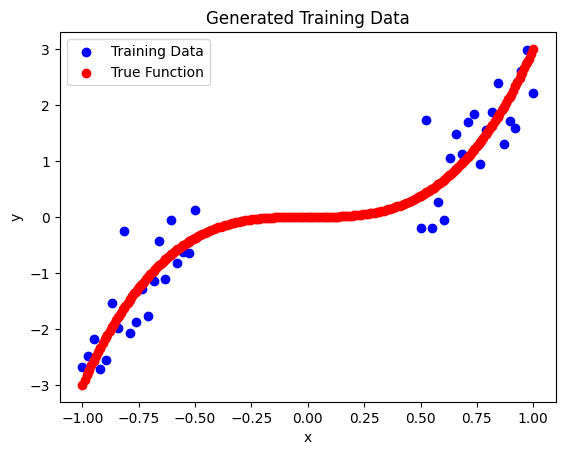

In [3]:
# data generation
x_train, y_train, x_test = generate_data(number_of_points=20, noise_variance=0.3)

# data visualization
plt.scatter(x_train, y_train, color='blue', label='Training Data')
plt.scatter(x_test, 3 * x_test**3, color='red', label='True Function')
plt.title('Generated Training Data')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()



### 1. Effect of Model Complexity

1. **(Effect of Model Complexity)** Generate a toy dataset with 40 observations (set the parameter `number_of_points=20` for `generate_data`, since twice the number of `number_of_points` will be generated), then  visualize the fit of MLE polynomial models, with degrees $D = [1, 3, 5, 10, 15, 20, 50, 100]$ - you should train on `x_train` and **visualize by predicting on `x_test` provided by the data generating function (`x_test` is a larger set of test points that includes `x_train`)**. You'll need to be thoughtful about your visualization so that these different models can be visually compared in a meaningful way. <br><br>
Discuss the effect of the choice of polynomial degree on the fit of the model (concretely describe why certaint choices are unideal in the context of the problem).

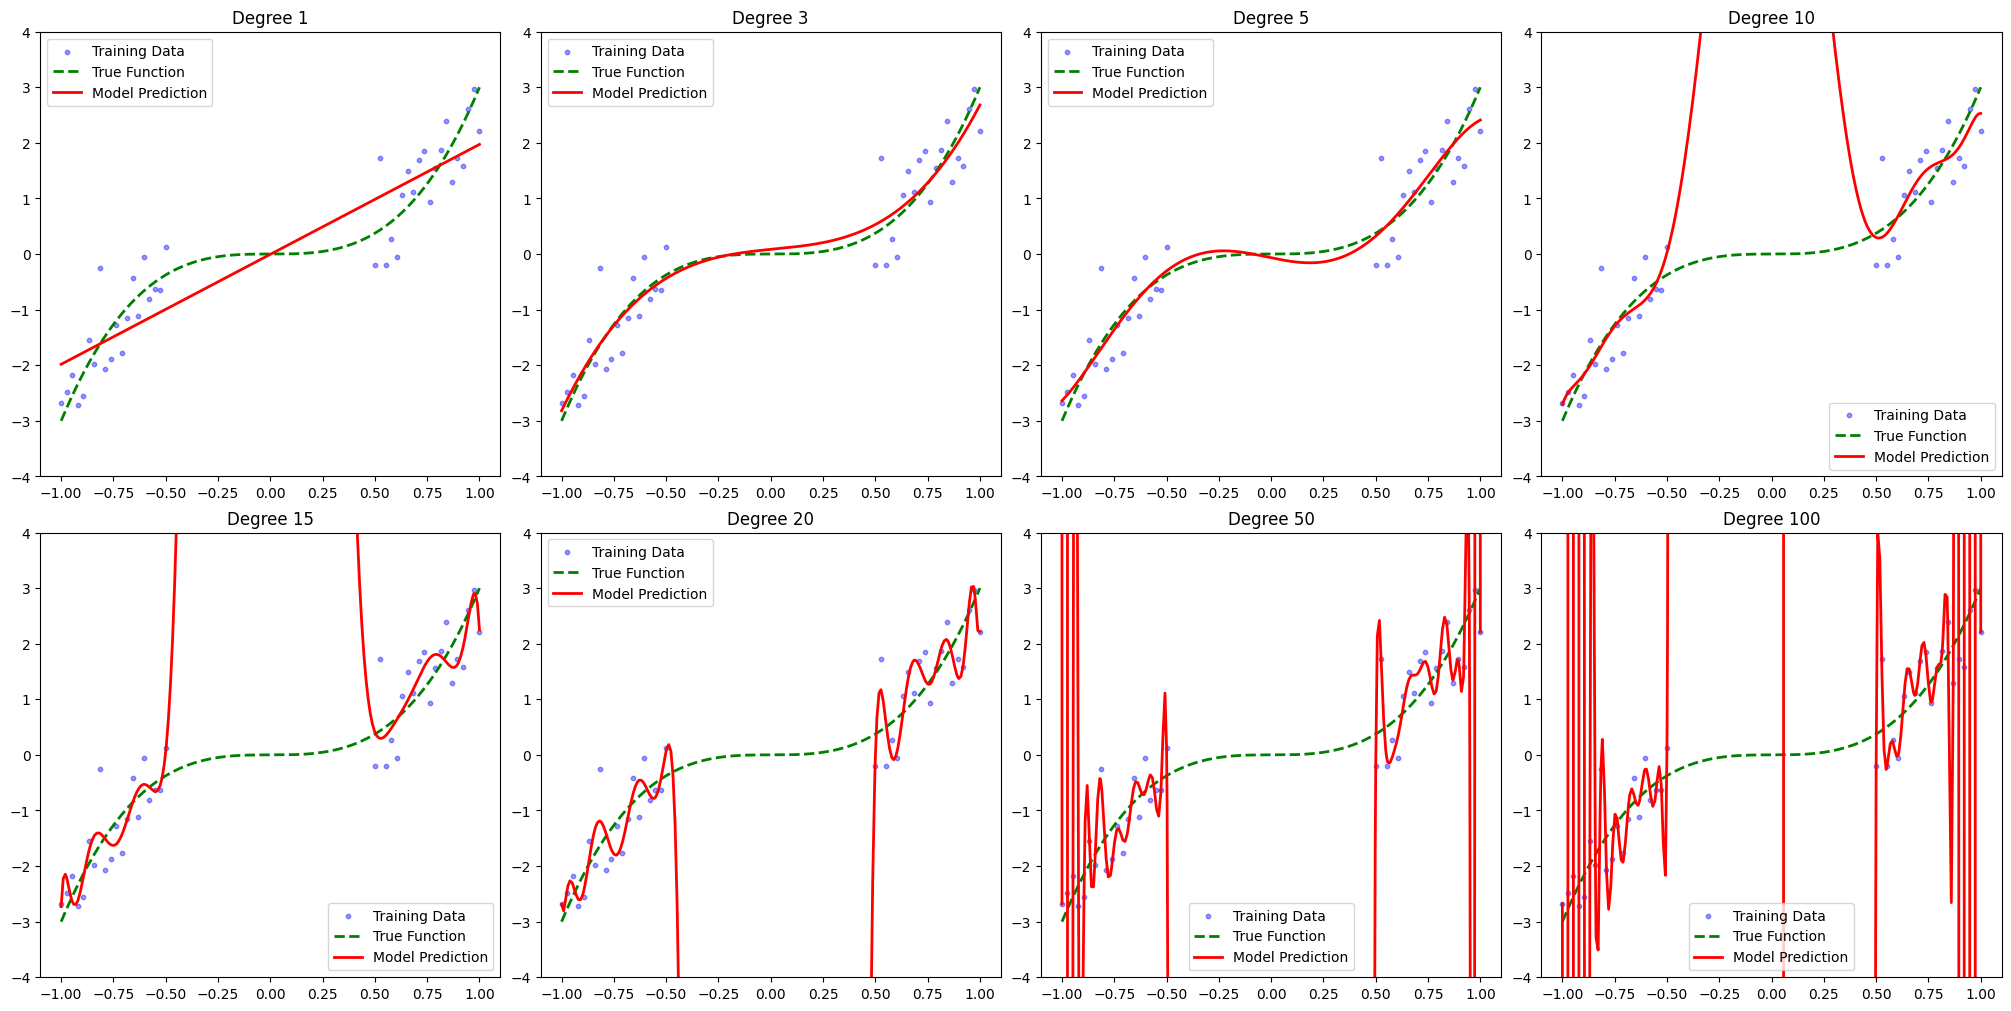

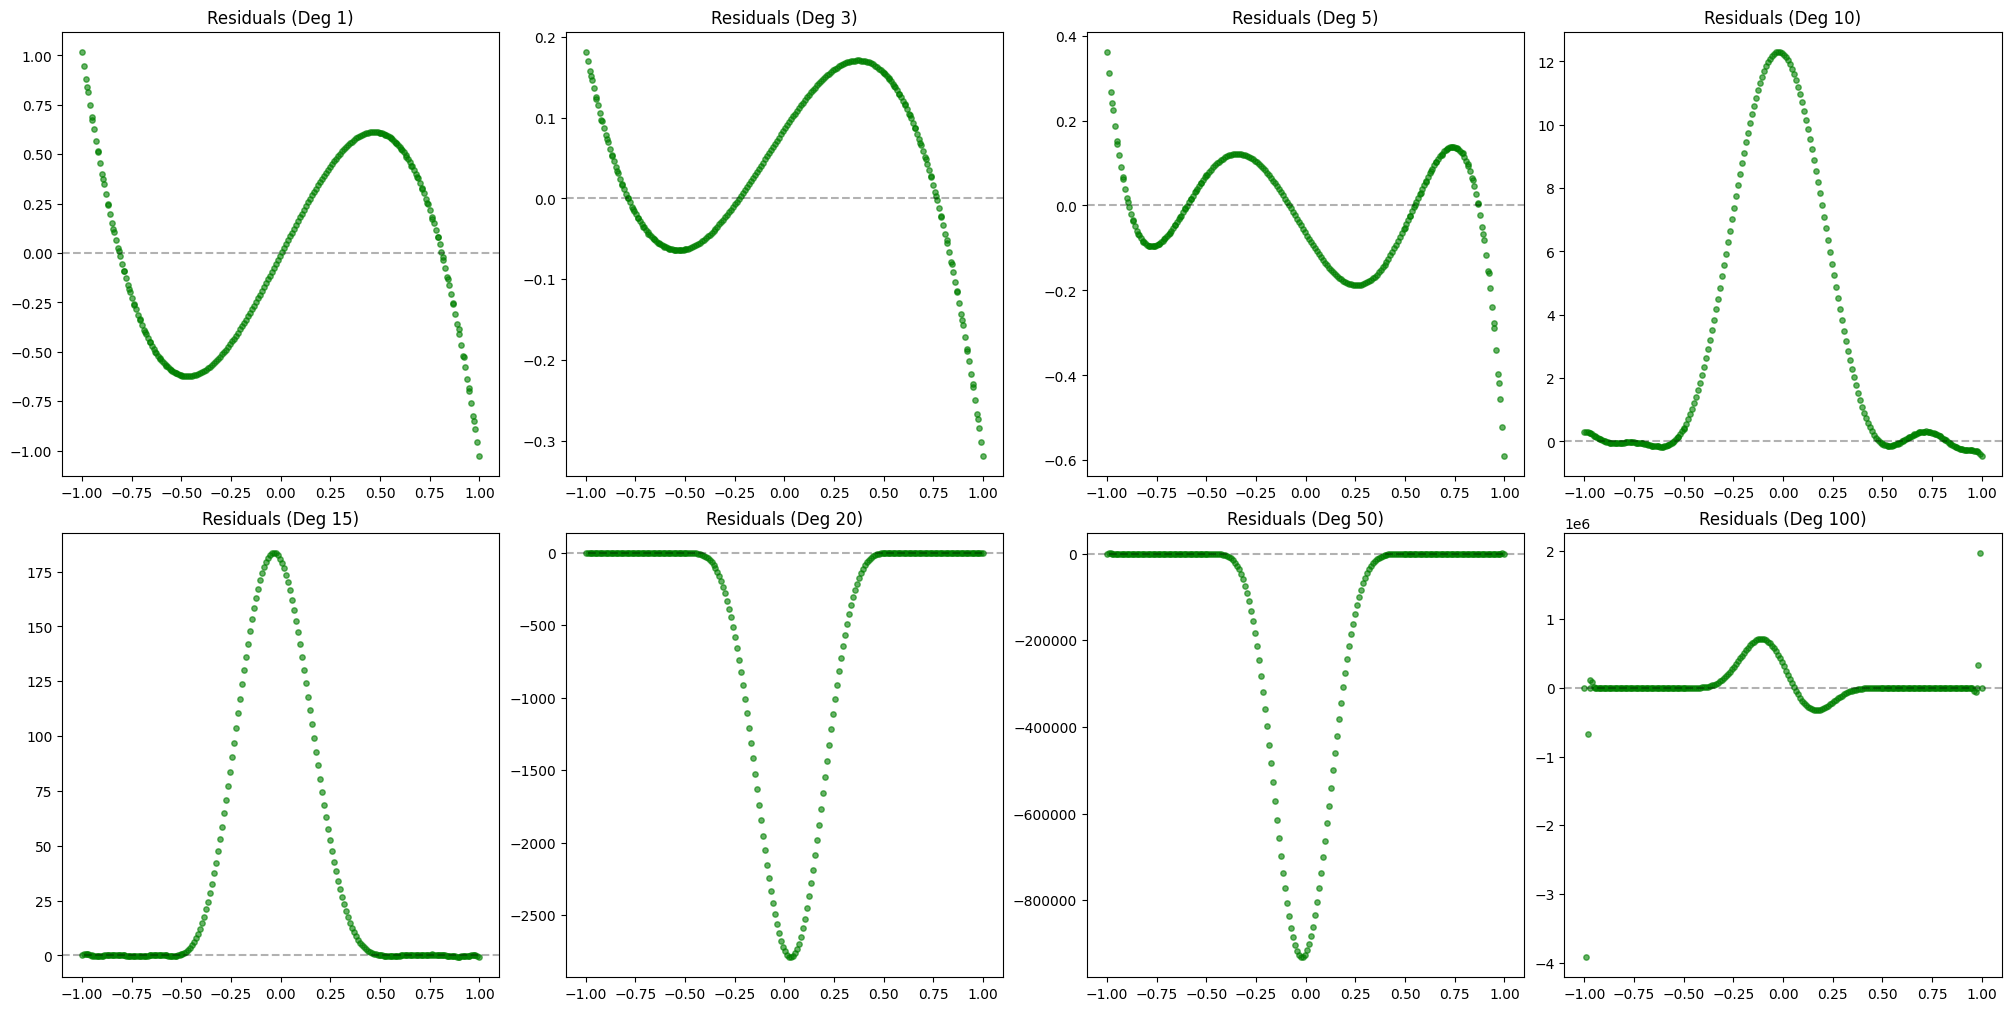

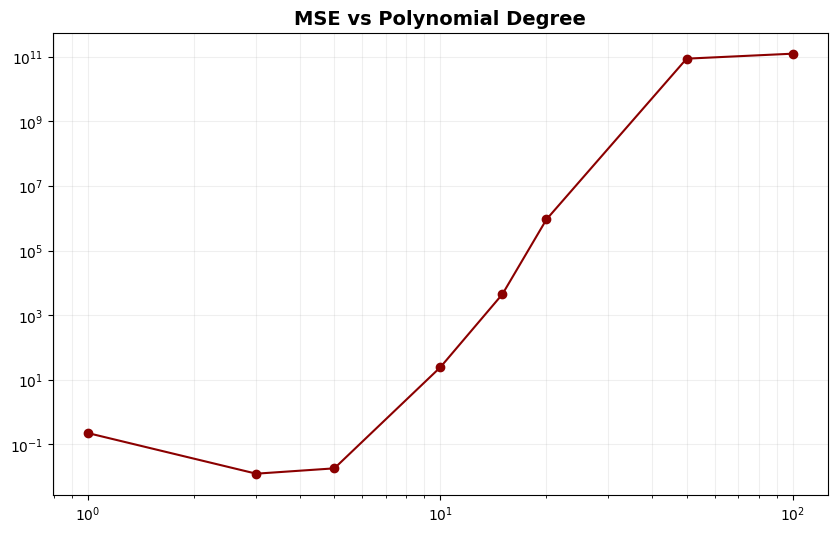

In [4]:
D = [1, 3, 5, 10, 15, 20, 50, 100]
mse_errors = []

fig1, axes1 = plt.subplots(2, 4, figsize=(20, 10), constrained_layout=True)
fig2, axes2 = plt.subplots(2, 4, figsize=(20, 10), constrained_layout=True)
axes1 = axes1.flatten()
axes2 = axes2.flatten()

#function relating x and y
def ground_truth(x):
    return 3 * x**3

for i, d in enumerate(D):
    # create polynomial features
    poly = PolynomialFeatures(degree=d, include_bias=True)
    x_train_poly = poly.fit_transform(x_train.reshape(-1, 1))
    x_test_poly = poly.transform(x_test.reshape(-1, 1))

    # fit linear regression model
    model = LinearRegression(fit_intercept=False)
    model.fit(x_train_poly, y_train)
    y_test_pred = model.predict(x_test_poly)

    #residuals against noise-free ground truth
    y_true = ground_truth(x_test)
    residuals = y_test_pred - y_true
    mse_errors.append(np.mean(residuals**2))

    #biais variance trade-off
    ax1 = axes1[i]
    ax1.scatter(x_train, y_train, color='blue', s=10, alpha=0.4, label='Training Data')
    ax1.plot(x_test, ground_truth(x_test), 'g--', label='True Function', linewidth=2)
    ax1.plot(x_test, y_test_pred, color='red', lw=2, label='Model Prediction')
    ax1.set_title(f'Degree {d}')
    ax1.set_ylim(-4, 4)
    ax1.legend()
    #error pattern
    ax2 = axes2[i]
    ax2.scatter(x_test, residuals, color='green', s=15, alpha=0.6)
    ax2.axhline(0, color='black', linestyle='--', alpha=0.3)
    ax2.set_title(f'Residuals (Deg {d})')

# error according degree
plt.figure(figsize=(10, 6))
plt.plot(D, mse_errors, marker='o', color='darkred')
plt.xscale('log')
plt.yscale('log')
plt.title('MSE vs Polynomial Degree', fontsize=14, fontweight='bold')
plt.grid(True, which="both", alpha=0.2)
plt.show()


<div style="background-color: #dde3fb; padding: 20px; border-radius: 5px; color: black;  box-sizing: border-box; width: 100%">
On the first plot, we observe that the degree 1 may seem a little bit two simple, that is to say underfitting. The models of degree 3 and 5 seems to be quite near of the data points. For the other fit, especially above degree 10, the models try too much to go throught each points what give a great example of overfitting. 

Smallest and most constant residuals seems to be the one linked to degree 3. Above degree 5, all residuals become larger and larger exponentially. 

My hypothesis is confirmed when we plot the MSE function to the polynomial degree. We can see that the error is the smallest for degree 3, and then it grows exponentially with the degree of the polynomial (log scale).
</div>

### 2. Model selection

2. **(Model Selection)** Later in the course, we will study a number of metrics commonly used for selecting between different MLE models. All of these metric essentially encode Occam's Razor: select the minimal complexity of model that satisfies some pre-determined modeling goal. <br><br>
For now, a very simple method for selecting the optimal degree is via cross-validation (by bootstrap):

  1. randomly sample two datasets, `x_train`, `x_valid`, from the data generating function: one for training and one for validation. Fit an MLE  polynomial model of degree $d$ on the training data and evaluate its performance on the validation data. Over $S$ number of such randomly sampled pairs of datasets, average the model's validation performance.
  2. plot the validation score as a function of model complexity, the polynomial degree $d$.
  3. based on the plot, select the the minimal degree that achieves a high average validation performance (i.e. look for the 'elbow' of the plot).

  Explain why performing model selection by cross-validation mitigates the risk of choosing an undesirable polynomial (identified in Problem 1)?<br><br>
  Implement model selection by cross-validation for the toy dataset generated in Problem 1 using MSE as your performance metric and select an optimal degree from $D=[1,3,5,10,15,20,50,100]$.

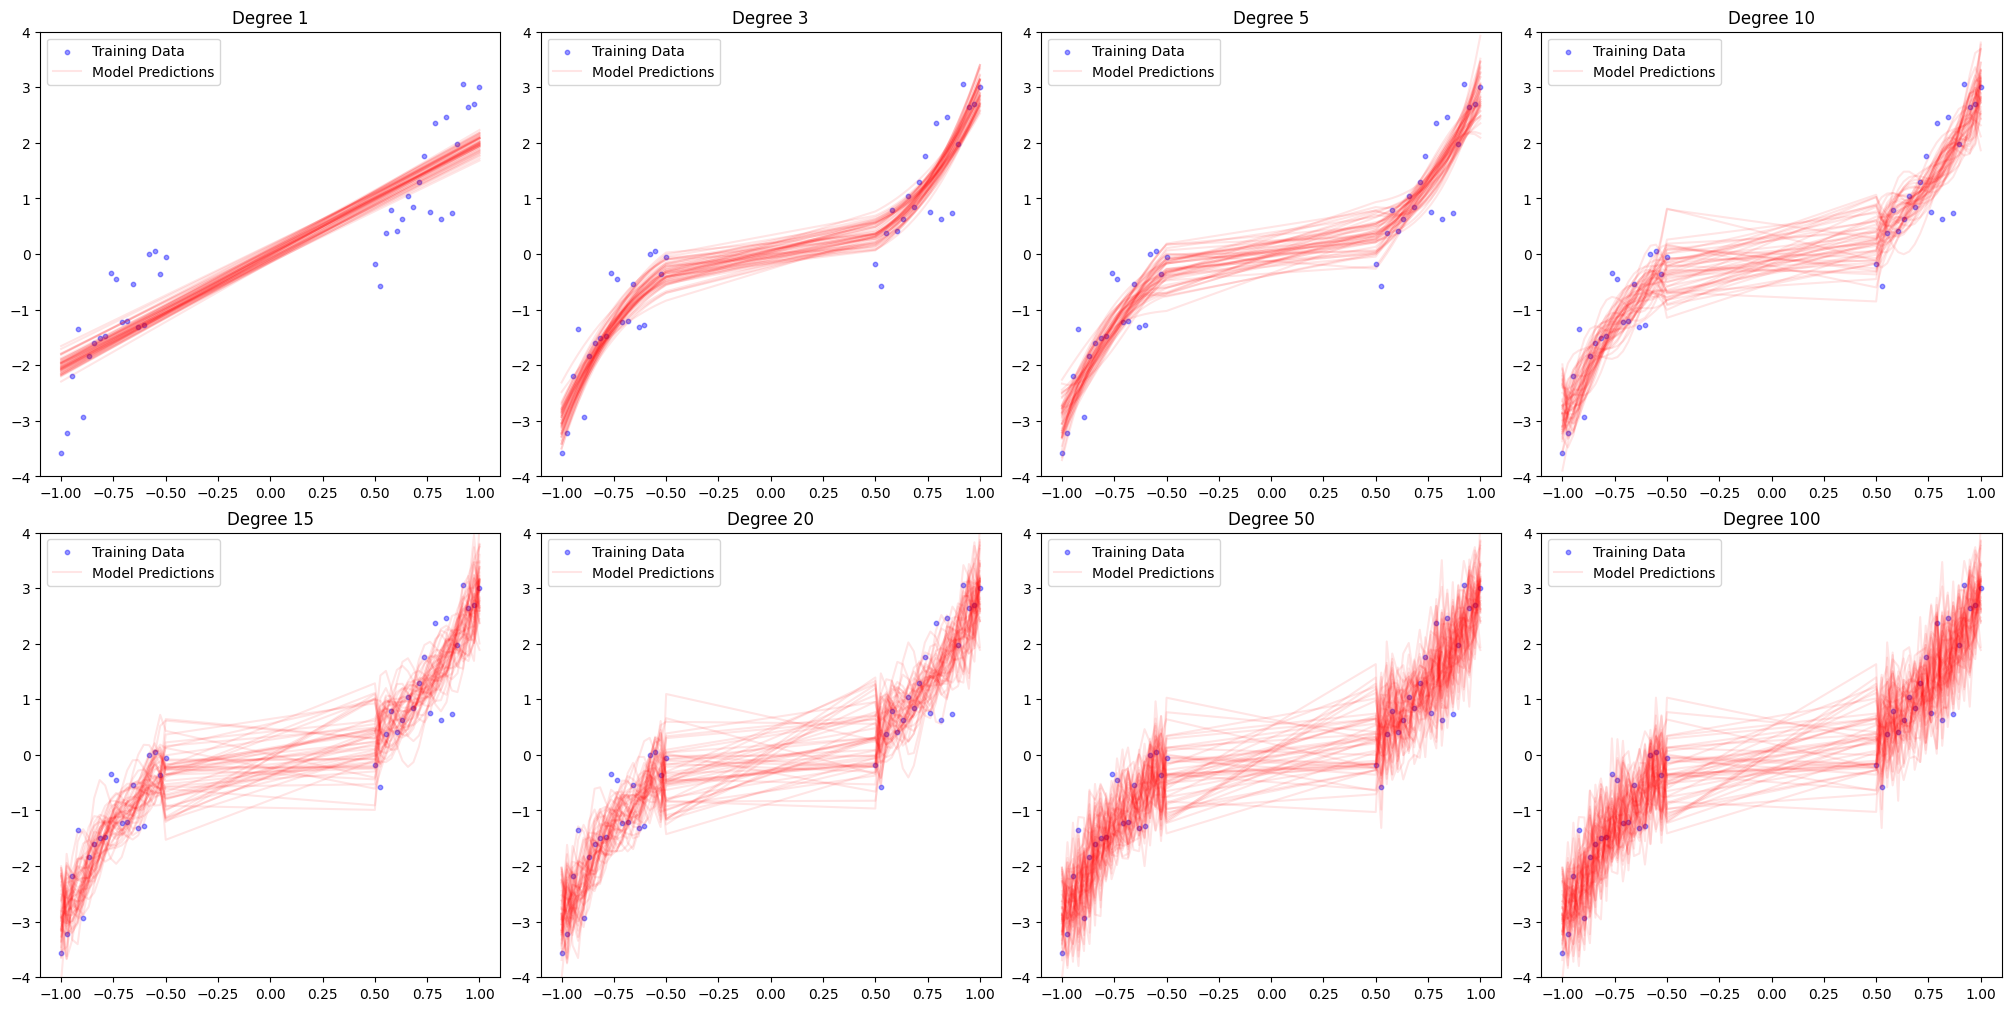

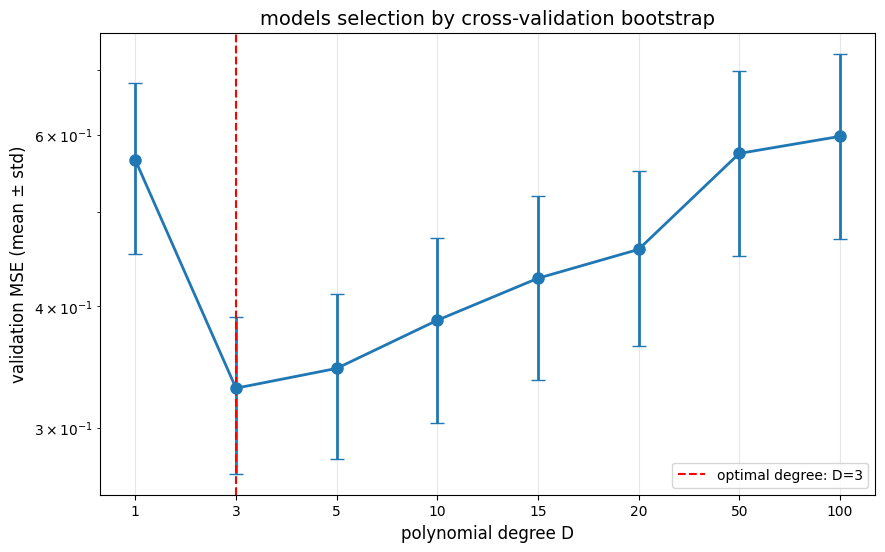

optimal degree selected: D = 3
mean MSE at optimal degree: 0.3294


In [5]:
# boostraping and cross validation method
D= [1, 3, 5, 10, 15, 20, 50, 100]
S=50
mse_errors_cv = {d: [] for d in D}
model_d = {d: [] for d in D}

for s in range(S):
    # randomly split the data into training and validation sets
    np.random.seed(s)
    x_train, y_train, _ = generate_data(number_of_points=20, noise_variance=0.3)
    
    # validation data
    np.random.seed(s + 1000)  # different seed for validation set
    x_validation, y_validation, _ = generate_data(number_of_points=20, noise_variance=0.3)
    
    for d in D:
        poly = PolynomialFeatures(degree=d, include_bias=True)
        x_train_poly = poly.fit_transform(x_train.reshape(-1, 1))
        x_validation_poly = poly.transform(x_validation.reshape(-1, 1))

        # model fitting and prediction
        model = LinearRegression(fit_intercept=False)
        model.fit(x_train_poly, y_train)
        y_validation_pred = model.predict(x_validation_poly)

        # compute validation error (MSE)
        validation_error = np.mean((y_validation_pred - y_validation) ** 2)
        mse_errors_cv[d].append(validation_error)
        model_d[d].append(y_validation_pred)

# for a given degree d, visualize the different fits obtained over the bootstrap samples
fig, axes = plt.subplots(2, 4, figsize=(20, 10), constrained_layout=True)
axes = axes.flatten() 

for i, d in enumerate(D):    
    # visualisation of the different fits for each degree
    ax1 = axes[i]
    ax1.scatter(x_train, y_train, color="blue", s=10, alpha=0.4, label="Training Data")
    for sample_pred in model_d[d]:
        ax1.plot(x_validation, sample_pred, color="red", alpha=0.1, label="Model Predictions" if sample_pred is model_d[d][0] else "")
    ax1.set_title(f"Degree {d}")
    ax1.set_ylim(-4, 4)
    ax1.legend()  

mean_mse_cv = {d: np.mean(errors) for d, errors in mse_errors_cv.items()}
mean_std_cv = {d: np.std(errors) for d, errors in mse_errors_cv.items()}

# visualisation of the mean and std of the MSE for each degree
plt.figure(figsize=(10, 6))
plt.errorbar(range(len(D)), mean_mse_cv.values(), yerr=mean_std_cv.values(), marker="o", capsize=5, linewidth=2, markersize=8)
plt.xticks(range(len(D)), D)
plt.xlabel("polynomial degree D", fontsize=12)
plt.ylabel("validation MSE (mean ± std)", fontsize=12)
plt.title("models selection by cross-validation bootstrap", fontsize=14)
plt.grid(True, alpha=0.3)
plt.yscale("log")

# Identifier le degré optimal (coude)
optimal_idx = np.argmin(list(mean_mse_cv.values()))
optimal_degree = D[optimal_idx]
plt.axvline(x=optimal_idx, color="r", linestyle="--", label=f"optimal degree: D={optimal_degree}")
plt.legend()
plt.show()

print(f"optimal degree selected: D = {optimal_degree}")
print(f"mean MSE at optimal degree: {mean_mse_cv[optimal_degree]:.4f}")

#### **Explain why performing model selection by cross-validation mitigates the risk of choosing an undesirable polynomial (identified in Problem 1)?**

<div style="background-color: #dde3fb; padding: 20px; border-radius: 5px; color: black;  box-sizing: border-box; width: 100%">

Performing model selection by cross-validation helps to **mitigate the risk of choosing an undesirable polynomial** by providing a more robust estimate of the model's performance on unseen data. In Problem 1, we observed that certain polynomial degrees led to overfitting or underfitting the training data. By using cross-validation, we can evaluate **how well each polynomial degree generalizes to new data** (the validation set) rather than just fitting the training data. Moreover, cross-validation **averages the performance over multiple splits of the data**, which reduce the variance in the performance estimate and helps to identify a polynomial degree that balances bias and variance effectively. This approach allows us to **select a model that is more likely to perform well in real-world** scenarios where the data distribution may differ from the training set, thus reducing the risk of selecting a polynomial that either overfits or underfits the data.

</div>

### 3. Uncertainty estimation

3. **(Uncertainty Estimation)** We often use the bootstrap predictive uncertainty of MLE models as an indicator of our confidence in the model's output. Increasingly, in practice, decisions making are deferred to human experts when the model's predictive uncertainty is too high. <br><br>
Given your understanding of the dataset (`x_train` and `x_test`), describe what the model uncertainty ***should*** ideally look like across the input space (i.e. if you plotted the model uncertainty as a function of $x$, what would it look like)? Justify your answer: consider the context of the problem - the test input has undergone covariate shift and is dissmilar to the training input, what kind of uncertainty would help you mitigate risk under this condition?<br><br>
A common practice for estimating predictive uncertainty is to fit a large number of (bootstrap) models on the training data (this collection of models is called an **ensemble**), then, at an input $x$, use the variance of the ensemble predictions to estimate the uncertainty at $x$. Plot the 95% predictive interval of 200 bootstrap MLE polynomial models for each degree $D=[1,3,5,10,15,20,50,100]$, arrange your plots as  subplots in a single figure. For which polynomial degree do you obtain the predictive uncertainty that is most ideal (according to your description above)? Is this the degree you selected in Problem 2? Explain why you would or would not expect the optimal degree in Problem 2 to yield the most ideal uncertainty estimate.<br><br>
Make the same plots the 95% predictive intervals for degrees $D=[1,3,5,10,15,20,50,100]$, with models fitted on larger training datasets - set `number_of_points` to 50, 100, 500, 1000 (arrange all these plots in a single figure). What is happening to the predictions of the ensemble in the training data rich region? What is happening to the predictions of the ensemble in the training data poor region? Are these expected behaviours (relate what you see in both cases to the asymptotic properties of MLE)?
<br><br>
When the training data is abundant (`number_of_points=1000`), are any of the 95% predictive intervals ideal (according to your description above)? What does this imply about the feasibility of using the variance of the ensemble predictions to estimate predictive uncertainty at an input $x$?

#### **Given your understanding of the dataset (`x_train` and `x_test`), describe what the model uncertainty ***should*** ideally look like across the input space (i.e. if you plotted the model uncertainty as a function of $x$, what would it look like)? Justify your answer: consider the context of the problem - the test input has undergone covariate shift and is dissmilar to the training input, what kind of uncertainty would help you mitigate risk under this condition?**

<div style="background-color: #dde3fb; padding: 20px; border-radius: 5px; color: black;  box-sizing: border-box; width: 100%">

The model uncertainty should ideally be low in the regions of the input space where we have training data ([-1, -0.5] and [0.5, 1]) and high in the regions where we have no training data (i.e., within the gap of [-0.5, 0.5]). This is because the model has seen data in the regions outside the gap and can make more confident predictions there, while it has not seen any data in the gap and thus should be less confident in its predictions there. This kind of uncertainty would help mitigate risk under covariate shift by flagging unreliable predictions in the gap region, allowing for human intervention or deferring decisions to experts when the model is uncertain.

As we can observe in the plots above, uncertainty is low in the [-0.5, 0.5] gap for the lower degree polynomials (1, 3, 5), which appears ideal at first glance but is fundamentally problematic: the model is overconfident in a region where it has no training data. The bootstrap variance fails to capture the epistemic uncertainty (lack of knowledge) that should exist in the gap.
For higher degree polynomials (10, 15, 20, 50, 100), the uncertainty is high in the gap, which correctly reflects the model's lack of knowledge in that region. However, for very high degrees (50, 100), the uncertainty becomes excessively high even in the regions with abundant training data, which is also problematic. This excessive uncertainty stems from model instability (overfitting): the high flexibility allows each bootstrap sample to fit wildly different functions, creating variance everywhere, not just where we lack data.

Thus, we face a fundamental trade-off: low-degree polynomials provide good predictive performance but underestimate uncertainty under covariate shift, while high-degree polynomials exhibit high uncertainty in the gap but suffer from poor predictions due to overfitting. No single polynomial degree yields both accurate predictions and ideal uncertainty estimates.

</div>

#### **A common practice for estimating predictive uncertainty is to fit a large number of (bootstrap) models on the training data (this collection of models is called an **ensemble**), then, at an input $x$, use the variance of the ensemble predictions to estimate the uncertainty at $x$. Plot the 95% predictive interval of 200 bootstrap MLE polynomial models for each degree $D=[1,3,5,10,15,20,50,100]$, arrange your plots as  subplots in a single figure**

To better understand, let's plot the 95% predictive intervals for degrees D=[1,3,5,10,15,20,50,100] with models fitted on larger training datasets (number_of_points=50, 100, 500, 1000).

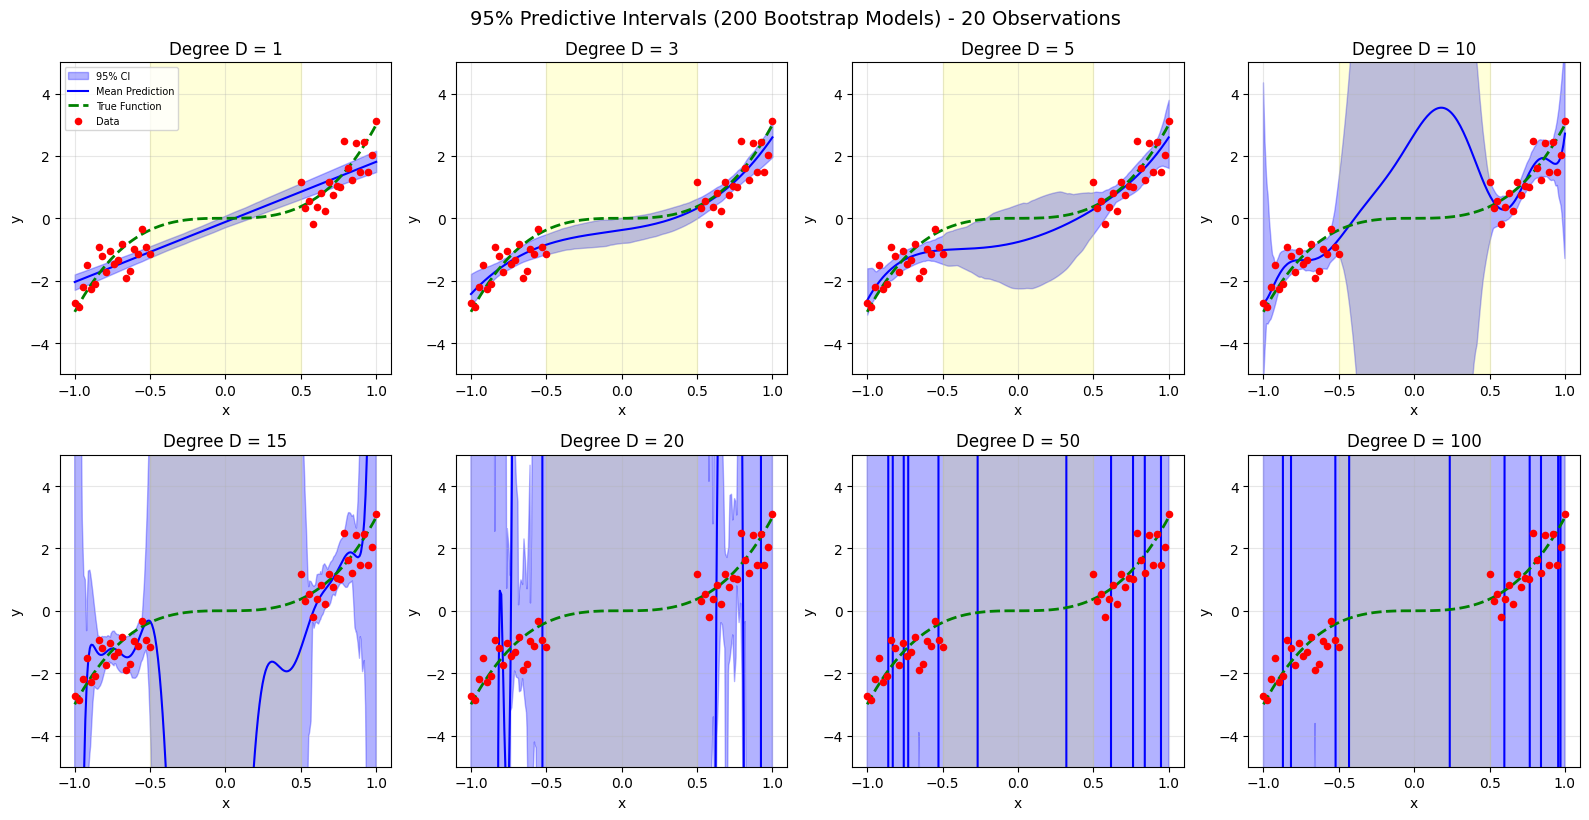

In [6]:
# boostraping and uncertainty estimation for model selection
D= [1, 3, 5, 10, 15, 20, 50, 100]

def bootstrap_model_selection(x_train, y_train, x_test, d, S):
    predictions = {d: [] for d in D}

    n_samples = len(x_train)

    for s in range(S):
        # create a bootstrap sample
        np.random.seed(s)
        indices = np.random.choice(n_samples, size=n_samples, replace=True)
        x_train_bootstrap = x_train[indices]
        y_train_bootstrap = y_train[indices]

        # create polynomial features
        poly = PolynomialFeatures(degree=d, include_bias=True)
        x_train_poly = poly.fit_transform(x_train_bootstrap.reshape(-1, 1))
        x_test_poly = poly.transform(x_test.reshape(-1, 1))

        #model fitting and prediction
        model = LinearRegression(fit_intercept=False,  n_jobs=-1)
        model.fit(x_train_poly, y_train_bootstrap)
        y_test_pred = model.predict(x_test_poly)

        #save predictions for each degree
        predictions[d].append(y_test_pred)
    return predictions

np.random.seed(42)
x_train, y_train, x_test = generate_data(number_of_points=20, noise_variance=0.3)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, d in enumerate(D):
    predictions = bootstrap_model_selection(x_train, y_train, x_test, d, S=200)
    
    # compute mean and 95% predictive interval
    mean_pred = np.mean(predictions[d], axis=0)
    lower = np.percentile(predictions[d], 2.5, axis=0)
    upper = np.percentile(predictions[d], 97.5, axis=0)
    
    ax = axes[i]
    ax.fill_between(x_test, lower, upper, alpha=0.3, color="blue", label="95% CI")
    ax.plot(x_test, mean_pred, "b-", linewidth=1.5, label="Mean Prediction")
    ax.plot(x_test, 3*x_test**3, "g--", linewidth=2, label="True Function")
    ax.scatter(x_train, y_train, c="red", s=20, zorder=5, label="Data")
    ax.axvspan(-0.5, 0.5, alpha=0.15, color="yellow")
    ax.set_xlim(-1.1, 1.1)
    ax.set_ylim(-5, 5)
    ax.set_title(f"Degree D = {d}")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.grid(True, alpha=0.3)
    if i == 0:
        ax.legend(fontsize=7, loc="upper left")

plt.tight_layout()
plt.suptitle("95% Predictive Intervals (200 Bootstrap Models) - 20 Observations", y=1.02, fontsize=14)
plt.show()

#### **For which polynomial degree do you obtain the predictive uncertainty that is most ideal (according to your description above)? Is this the degree you selected in Problem 2? Explain why you would or would not expect the optimal degree in Problem 2 to yield the most ideal uncertainty estimate.**

<div style="background-color: #dde3fb; padding: 20px; border-radius: 5px; color: black;  box-sizing: border-box; width: 100%">

The 10 degree polynomial seems to provide the most ideal predictive uncertainty. It captures the low uncertainty in the regions with training data and high uncertainty in the gap, which aligns with our expectations under covariate shift. In problem 2, we identified degree 3 as the optimal degree based on validation performance. However, degree 3 underestimates uncertainty in the gap region, which is a critical issue under covariate shift. This discrepancy arises because model selection based on validation performance focuses on predictive accuracy rather than uncertainty estimation. The optimal degree for prediction may not be the optimal degree for uncertainty estimation, especially in scenarios with covariate shift where capturing epistemic uncertainty is crucial for risk mitigation.

</div>

#### **Make the same plots the 95% predictive intervals for degrees $D=[1,3,5,10,15,20,50,100]$, with models fitted on larger training datasets - set `number_of_points` to 50, 100, 500, 1000 (arrange all these plots in a single figure).**

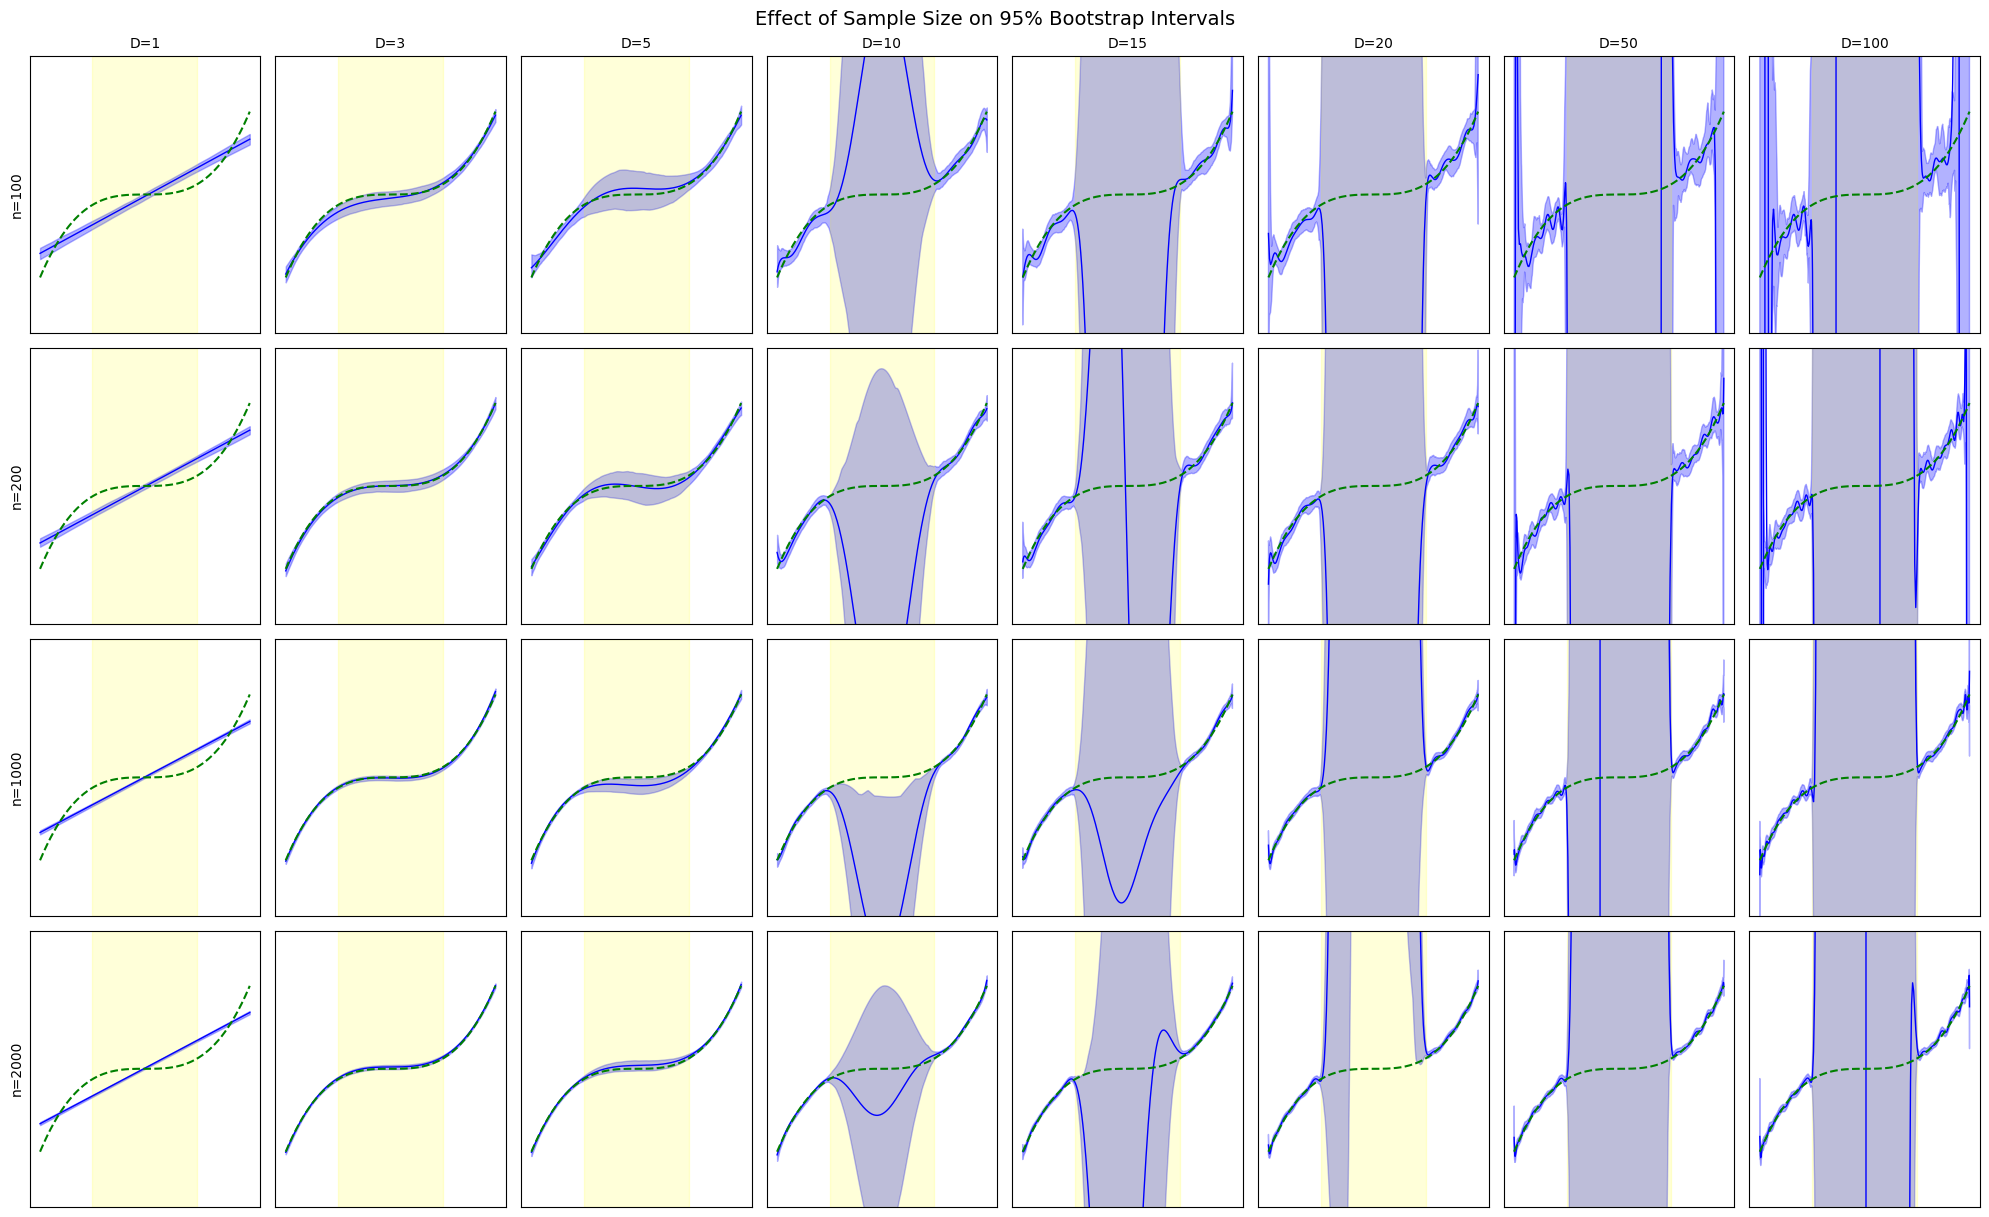

In [7]:
np.random.seed(42)
number_of_points = [50, 100, 500, 1000]

fig, axes = plt.subplots(len(number_of_points), len(D), figsize=(20, 12))

for row, n_points in enumerate(number_of_points):
    np.random.seed(42)
    x_train, y_train, x_test = generate_data(number_of_points=n_points)
    
    for col, d in enumerate(D):
        predictions = bootstrap_model_selection(x_train, y_train, x_test, d, S=200)
        
        mean_pred = np.mean(predictions[d], axis=0)
        lower = np.percentile(predictions[d], 2.5, axis=0)
        upper = np.percentile(predictions[d], 97.5, axis=0)
        
        ax = axes[row, col]
        ax.fill_between(x_test, lower, upper, alpha=0.3, color="blue")
        ax.plot(x_test, mean_pred, "b-", linewidth=1)
        ax.plot(x_test, 3*x_test**3, "g--", linewidth=1.5)
        ax.axvspan(-0.5, 0.5, alpha=0.15, color="yellow")
        ax.set_xlim(-1.1, 1.1)
        ax.set_ylim(-5, 5)
        
        if row == 0:
            ax.set_title(f"D={d}", fontsize=10)
        if col == 0:
            ax.set_ylabel(f"n={2*n_points}", fontsize=10)
        
        ax.set_xticks([])
        ax.set_yticks([])

plt.tight_layout()
plt.suptitle("Effect of Sample Size on 95% Bootstrap Intervals", y=1.01, fontsize=14)
plt.show()

#### **What is happening to the predictions of the ensemble in the training data rich region? What is happening to the predictions of the ensemble in the training data poor region? Are these expected behaviours (relate what you see in both cases to the asymptotic properties of MLE)?**

<div style="background-color: #dde3fb; padding: 20px; border-radius: 5px; color: black;  box-sizing: border-box; width: 100%">

In the training data rich regions ([-1, -0.5] and [0.5, 1]), as the number of training points increases (50 to 1000), the predictions of the ensemble become more stable and converge towards the true underlying function. This is expected due to the asymptotic properties of MLE: as the sample size increases, the MLE estimates converge to the true parameter values, leading to more accurate predictions and reduced variance in those predictions.

In the training data poor region (the gap of [-0.5, 0.5]), the predictions of the ensemble become also more stable as we can see on the 10 degree polynomial plot. However, this behavior is problematic: the model is becoming more confident in a region where it has no training data. The models become more and more confidant even using extrapolated data. This is a consequence of the fact that MLE does not capture epistemic uncertainty (lack of knowledge) in regions without data, and as we increase the number of training points, the model becomes more certain about its predictions even in the gap, which is a critical issue under covariate shift.

</div>

#### **When the training data is abundant (`number_of_points=1000`), are any of the 95% predictive intervals ideal (according to your description above)? What does this imply about the feasibility of using the variance of the ensemble predictions to estimate predictive uncertainty at an input $x$?**

<div style="background-color: #dde3fb; padding: 20px; border-radius: 5px; color: black;  box-sizing: border-box; width: 100%">

No, even when the number of points is abundant, none of the 95% predictive intervals are ideal. The low-degree polynomials (1, 3, 5) still underestimate uncertainty in the gap region, while the high-degree polynomials (50, 100) exhibit either very high uncertainty in the gap, either uncertainty doesn't even contain the true function in the training data poor region (D=10, s=1000). This implies that using the variance of the ensemble predictions to estimate predictive uncertainty at an input $x$ is not always feasible, especially under covariate shift. The bootstrap variance fails to capture epistemic uncertainty in regions without data, and can also be inflated due to model instability in high-degree polynomials, leading to unreliable uncertainty estimates.

</div>

### Effect of regularization

4. **(Effect of Regularization)** In practice, MLE models are nearly always trained with regularization (since they tend to overfit to the training data). Here, we will explore the effect of adding $\ell_2$ regularization to our MLE polynomial models (that is, use the `Ridge` regression model from `sklearn` after augmenting your input with polynomial features). <br><br>
For a toy dataset with 40 observations (`number_of_points=20`), plot the 95% predictive intervals for degrees $D = [1,3,5,10,15,20,50,100]$ and regularization strengths `alpha = [5e-3, 1e-2, 1e-1, 1e0, 1e1]` (you should organize these plots in a grid).<br><br>
Describe the effect of regularization on the bootstrap uncertainties. Looking at these results, are the goals of $\ell_2$ regularization and obtaining useful predictive uncertatinty estimation neccessarily well-aligned?


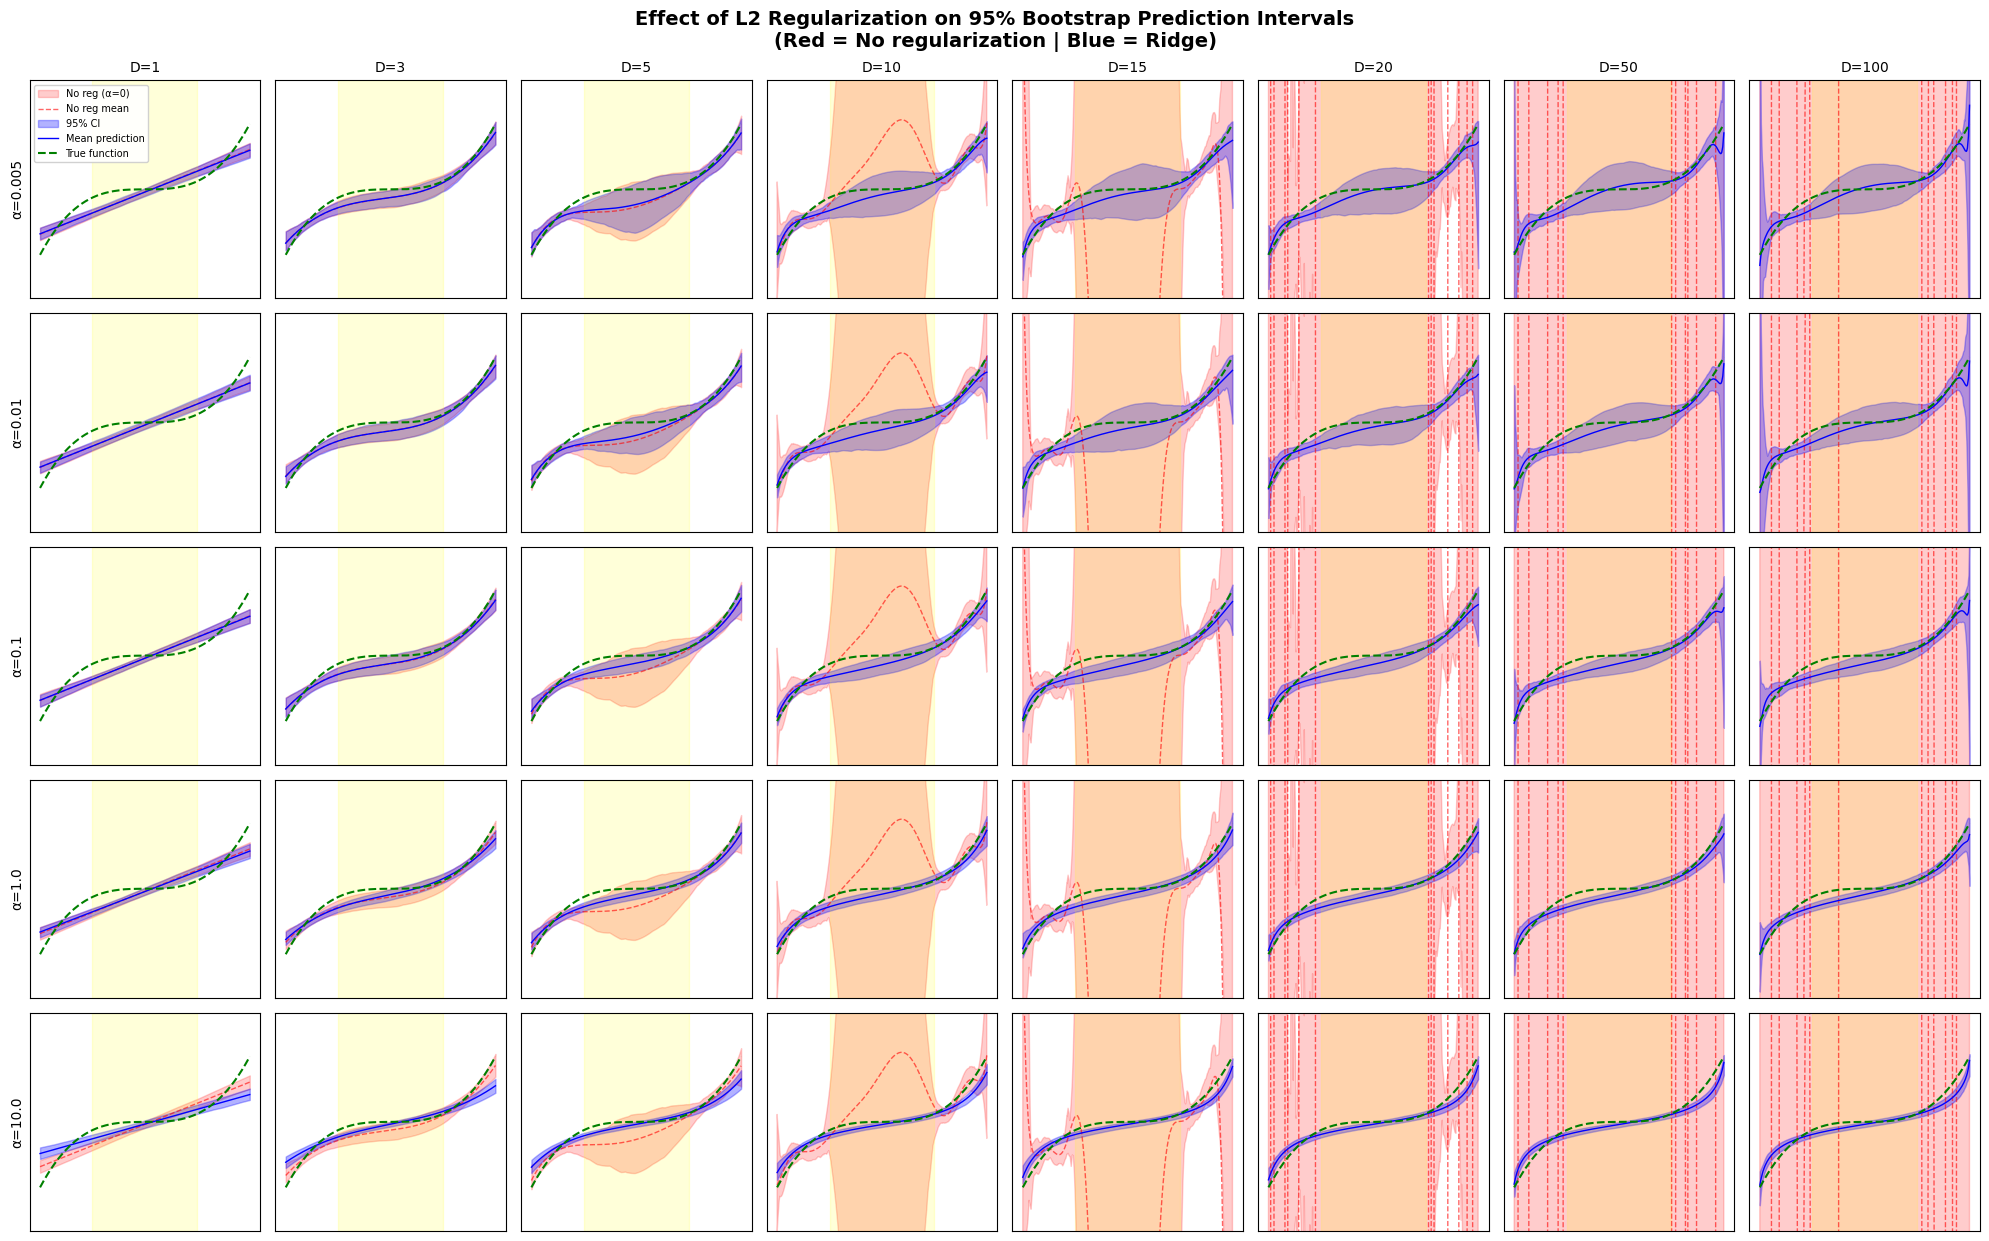

In [8]:
# generate single dataset for all experiments
np.random.seed(42)
x_train, y_train, x_test = generate_data(number_of_points=20, noise_variance=0.3)

# regularization strengths and polynomial degrees
alphas = [5e-3, 1e-2, 1e-1, 1e0, 1e1]
D = [1, 3, 5, 10, 15, 20, 50, 100]

def bootstrap_ensemble_model_ridge_regularized(x_train, y_train, x_test, degree, alpha=None, n_bootstrap=200):
    n = len(x_train)
    predictions = np.zeros((n_bootstrap, len(x_test)))
    
    poly = PolynomialFeatures(degree=degree, include_bias=True)
    if alpha is None:
        model = LinearRegression(fit_intercept=False)
    else:
        model = Ridge(alpha=alpha, fit_intercept=False)
    
    for b in range(n_bootstrap):
        #bootstrap sample (with replacement)
        idx = np.random.choice(n, size=n, replace=True)
        x_b = x_train[idx]
        y_b = y_train[idx]
        
        #transform and fit
        X_b_poly = poly.fit_transform(x_b.reshape(-1, 1))
        X_test_poly = poly.transform(x_test.reshape(-1, 1))
        
        model.fit(X_b_poly, y_b)
        predictions[b] = model.predict(X_test_poly)
    
    return predictions

#compute reference intervals without regularization
reference_intervals = {}
for degree in D:
    predictions_no_reg = bootstrap_ensemble_model_ridge_regularized(x_train, y_train, x_test, degree, alpha=None, n_bootstrap=200)
    reference_intervals[degree] = {
        'lower': np.percentile(predictions_no_reg, 2.5, axis=0),
        'upper': np.percentile(predictions_no_reg, 97.5, axis=0),
        'mean': np.mean(predictions_no_reg, axis=0)
    }

# visualization grid
fig, axes = plt.subplots(len(alphas), len(D), figsize=(20, 12))

for row, alpha_val in enumerate(alphas):
    for col, degree in enumerate(D):
        #get bootstrap predictions
        predictions = bootstrap_ensemble_model_ridge_regularized(x_train, y_train, x_test, degree, alpha_val, n_bootstrap=200)
        
        #compute mean and 95% CI
        mean_pred = np.mean(predictions, axis=0)
        lower = np.percentile(predictions, 2.5, axis=0)
        upper = np.percentile(predictions, 97.5, axis=0)
        
        ax = axes[row, col]
        ax.fill_between(x_test, 
                        reference_intervals[degree]['lower'], 
                        reference_intervals[degree]['upper'], 
                        alpha=0.2, color='red', label='No reg (α=0)')
        ax.plot(x_test, reference_intervals[degree]['mean'], 'r--', linewidth=1, alpha=0.6, label='No reg mean')
        ax.fill_between(x_test, lower, upper, alpha=0.3, color='blue', label='95% CI')
        ax.plot(x_test, mean_pred, 'b-', linewidth=1, label='Mean prediction')
        ax.plot(x_test, 3*x_test**3, 'g--', linewidth=1.5, label='True function')
        ax.axvspan(-0.5, 0.5, alpha=0.15, color='yellow')  # Training region
        
        ax.set_xlim(-1.1, 1.1)
        ax.set_ylim(-5, 5)
        
        if row == 0:
            ax.set_title(f'D={degree}', fontsize=10)
        if col == 0:
            ax.set_ylabel(f'α={alpha_val}', fontsize=10)
        
        ax.set_xticks([])
        ax.set_yticks([])
        
        if row == 0 and col == 0:
            ax.legend(loc='upper left', fontsize=7, framealpha=0.9)

plt.tight_layout()
plt.suptitle('Effect of L2 Regularization on 95% Bootstrap Prediction Intervals\n(Red = No regularization | Blue = Ridge)', y=1.03, fontsize=14, fontweight='bold')
plt.show()

#### **Describe the effect of regularization on the bootstrap uncertainties.**

<div style="background-color: #dde3fb; padding: 20px; border-radius: 5px; color: black;  box-sizing: border-box; width: 100%">

**For low polynomial degrees (D=1, 3, 5):**
For low regularization strengths (α = 5e-3, 1e-2), the predictive intervals are quite similar to those without regularization. We observe prediction zones where the interval width increases with degree and decreases as alpha increases.
When alpha increases, the mean predictions become smoother, the confidence intervals become narrower and no longer contain the true function.

**For high polynomial degrees (D=20, 50, 100):**
For low regularization strengths, the predictive intervals are much narrower than without regularization, which is a good thing. However, for higher regularization strengths, the predictive intervals become excessively narrow and overconfident, even in the extrapolation region (outside the yellow training zone), which is problematic. This excessive confidence stems from the fact that L2 regularization penalizes large coefficients, which can lead to underfitting and a failure to capture the true underlying function, especially in regions where the model extrapolates beyond its training data.


In general, regularization reduces the variance of the model predictions, which leads to narrower predictive intervals.

</div>

#### **Looking at these results, are the goals of $\ell_2$ regularization and obtaining useful predictive uncertatinty estimation neccessarily well-aligned?**

<div style="background-color: #dde3fb; padding: 20px; border-radius: 5px; color: black;  box-sizing: border-box; width: 100%">

**No, the goals are not necessarily well-aligned.**

The primary goal of L2 regularization is to reduce overfitting by penalizing large coefficients, thereby decreasing model variance at the cost of slightly increased bias.
In contrast, useful uncertainty estimation aims to provide high uncertainty in regions where the model has limited or no data—specifically outside the training domain (the yellow region)—to honestly reflect the model's lack of confidence when extrapolating.

Since regularization reduces variance uniformly across all regions, it fails to distinguish between interpolation zones (where uncertainty should be low) and extrapolation zones (where uncertainty should be high). This is particularly problematic when α is large: the model becomes artificially overconfident everywhere, producing narrow intervals even in regions where predictions are unreliable.

For high degrees with strong regularization (bottom-right corner), the blue intervals are deceptively narrow, suggesting high confidence, yet the mean prediction (blue line) systematically deviates from the true function (green dashed line), especially in extrapolation. This narrow interval reflects only the reduced variance but completely misses the systematic bias introduced by over-regularization.

L2 regularization achieves its variance-reduction goal but at the expense of producing misleading uncertainty estimates. Bootstrap intervals after regularization capture sampling variability but fail to account for model misspecification bias, making them unreliable indicators of true predictive uncertainty.

</div>

## Part II: Bayesian Polynomial Regression
In this problem, your task is to perform Bayesian polynomial regression on the toy datasets in Part I. That is, assume that the outcome $y$ can be modeled by the following process:

\begin{align}
y &= f(x) + \epsilon = w_0 + w_1x + w_2x^2 + \ldots + w_Dx^D + \epsilon, \quad \epsilon \sim N(0, 0.3)\\
w_d &\sim N(0, \alpha)
\end{align}

where $\alpha$ is a hyperparameter and must be fixed before modeling and inference begins.

### 1. Bayesian Kernel Regression

1. **(Bayesian Kernel Regression)** Just as we can treat a polynomial regression model like a multi-linear regression model after ***transforming*** the input data by adding polynomial features. We can treat Bayesian polynomial regression like Bayesian linear regression on top of the transformed inputs. Formally, the map that takes an input $\mathbf{x}_n \in \mathbb{R}^{D'}$ and transforms it into a new input $\phi(\mathbf{x}_n) \in \mathbb{R}^{D}$ is called a **feature map**, $\phi: \mathbb{R}^{D'} \to \mathbb{R}^{D}$, for 1-dimensional input $x \in \mathbb{R}$, the polynomial feature map of degree $D$ is defined by
\begin{align}
\\\phi: \mathbb{R} &\to \mathbb{R}^D\\
x &\mapsto [1, x, x^2, \ldots, x^D]\\
\end{align}
<br> Thus, we can write rewrite Bayesian polynomial regression as
\begin{align}
\\y &= \mathbf{w}^\top \mathbf{x} + \epsilon, \quad \epsilon \sim {N}(0, 0.3)\\
\mathbf{w} &\sim {N}(0, \alpha I_{D\times D})\\
\end{align}
<br>Denote the $N\times D$ matrix of transformed inputs by $\Phi$, where the $n$-th row of the matrix is the $n$-th input $\mathbf{x}_n$ transformed by the feature map, $\phi(\mathbf{x}_n)$. 

#### **Using this notation, write out the closed form for the posterior for Bayesian polynomial regression in terms of $\Phi$.**

<div style="background-color: #dde3fb; padding: 20px; border-radius: 5px; color: black;  box-sizing: border-box; width: 100%">

We have the following model:
$$y = \Phi \mathbf{w} + \epsilon, \quad \epsilon \sim \mathcal{N}(0, \sigma^2), \quad \sigma^2 = 0.3$$

Prior:
$$\mathbf{w} \sim \mathcal{N}(0, \alpha I_{D\times D})$$

Likelihood:
$$\mathbf{y}|\Phi, \mathbf{w} \sim \mathcal{N}(\Phi \mathbf{w}, \sigma^2 I_{N\times N})$$

Posterior:
\begin{align}
p(\mathbf{w}|\mathbf{y}, \Phi) &\propto p(\mathbf{y}|\Phi, \mathbf{w}) p(\mathbf{w})\\
&= \mathcal{N}(\mathbf{y}|\Phi \mathbf{w}, \sigma^2 I_{N\times N}) \mathcal{N}(\mathbf{w}|0, \alpha I_{D\times D})\\
&= \mathcal{N}(\mathbf{w}|\boldsymbol{\mu}, \boldsymbol{\Sigma})
\end{align}
$$\boxed{p(\mathbf{w} | \mathbf{y}, \Phi) = \mathcal{N}(\boldsymbol{\mu}, \boldsymbol{\Sigma})}$$

where
$$\boxed{\boldsymbol{\Sigma} = \left(\frac{1}{\sigma^2} \Phi^\top \Phi + \frac{1}{\alpha} I_{D\times D}\right)^{-1}}$$
$$\boxed{\boldsymbol{\mu} = \boldsymbol{\Sigma} \left(\frac{1}{\sigma^2} \Phi^\top \mathbf{y}\right)}$$

</div>

### 2. Effect of Model Complexity

2. **(Effect of Model Complexity)** For Bayesian kernel regression, you need to pre-determine the number of features (i.e. $D$) and the hyperparameter $\alpha$ in the prior. For a toy dataset with 40 observations (set number_of_points=20), visualize the 95% posterior predictive interval for $D = [1,3,5,10,15,20,50,100]$ and $\alpha = [0.1, 1, 5, 10, 100]$ (arrange these visualizations in a grid), using Bayesian polynomial regression.

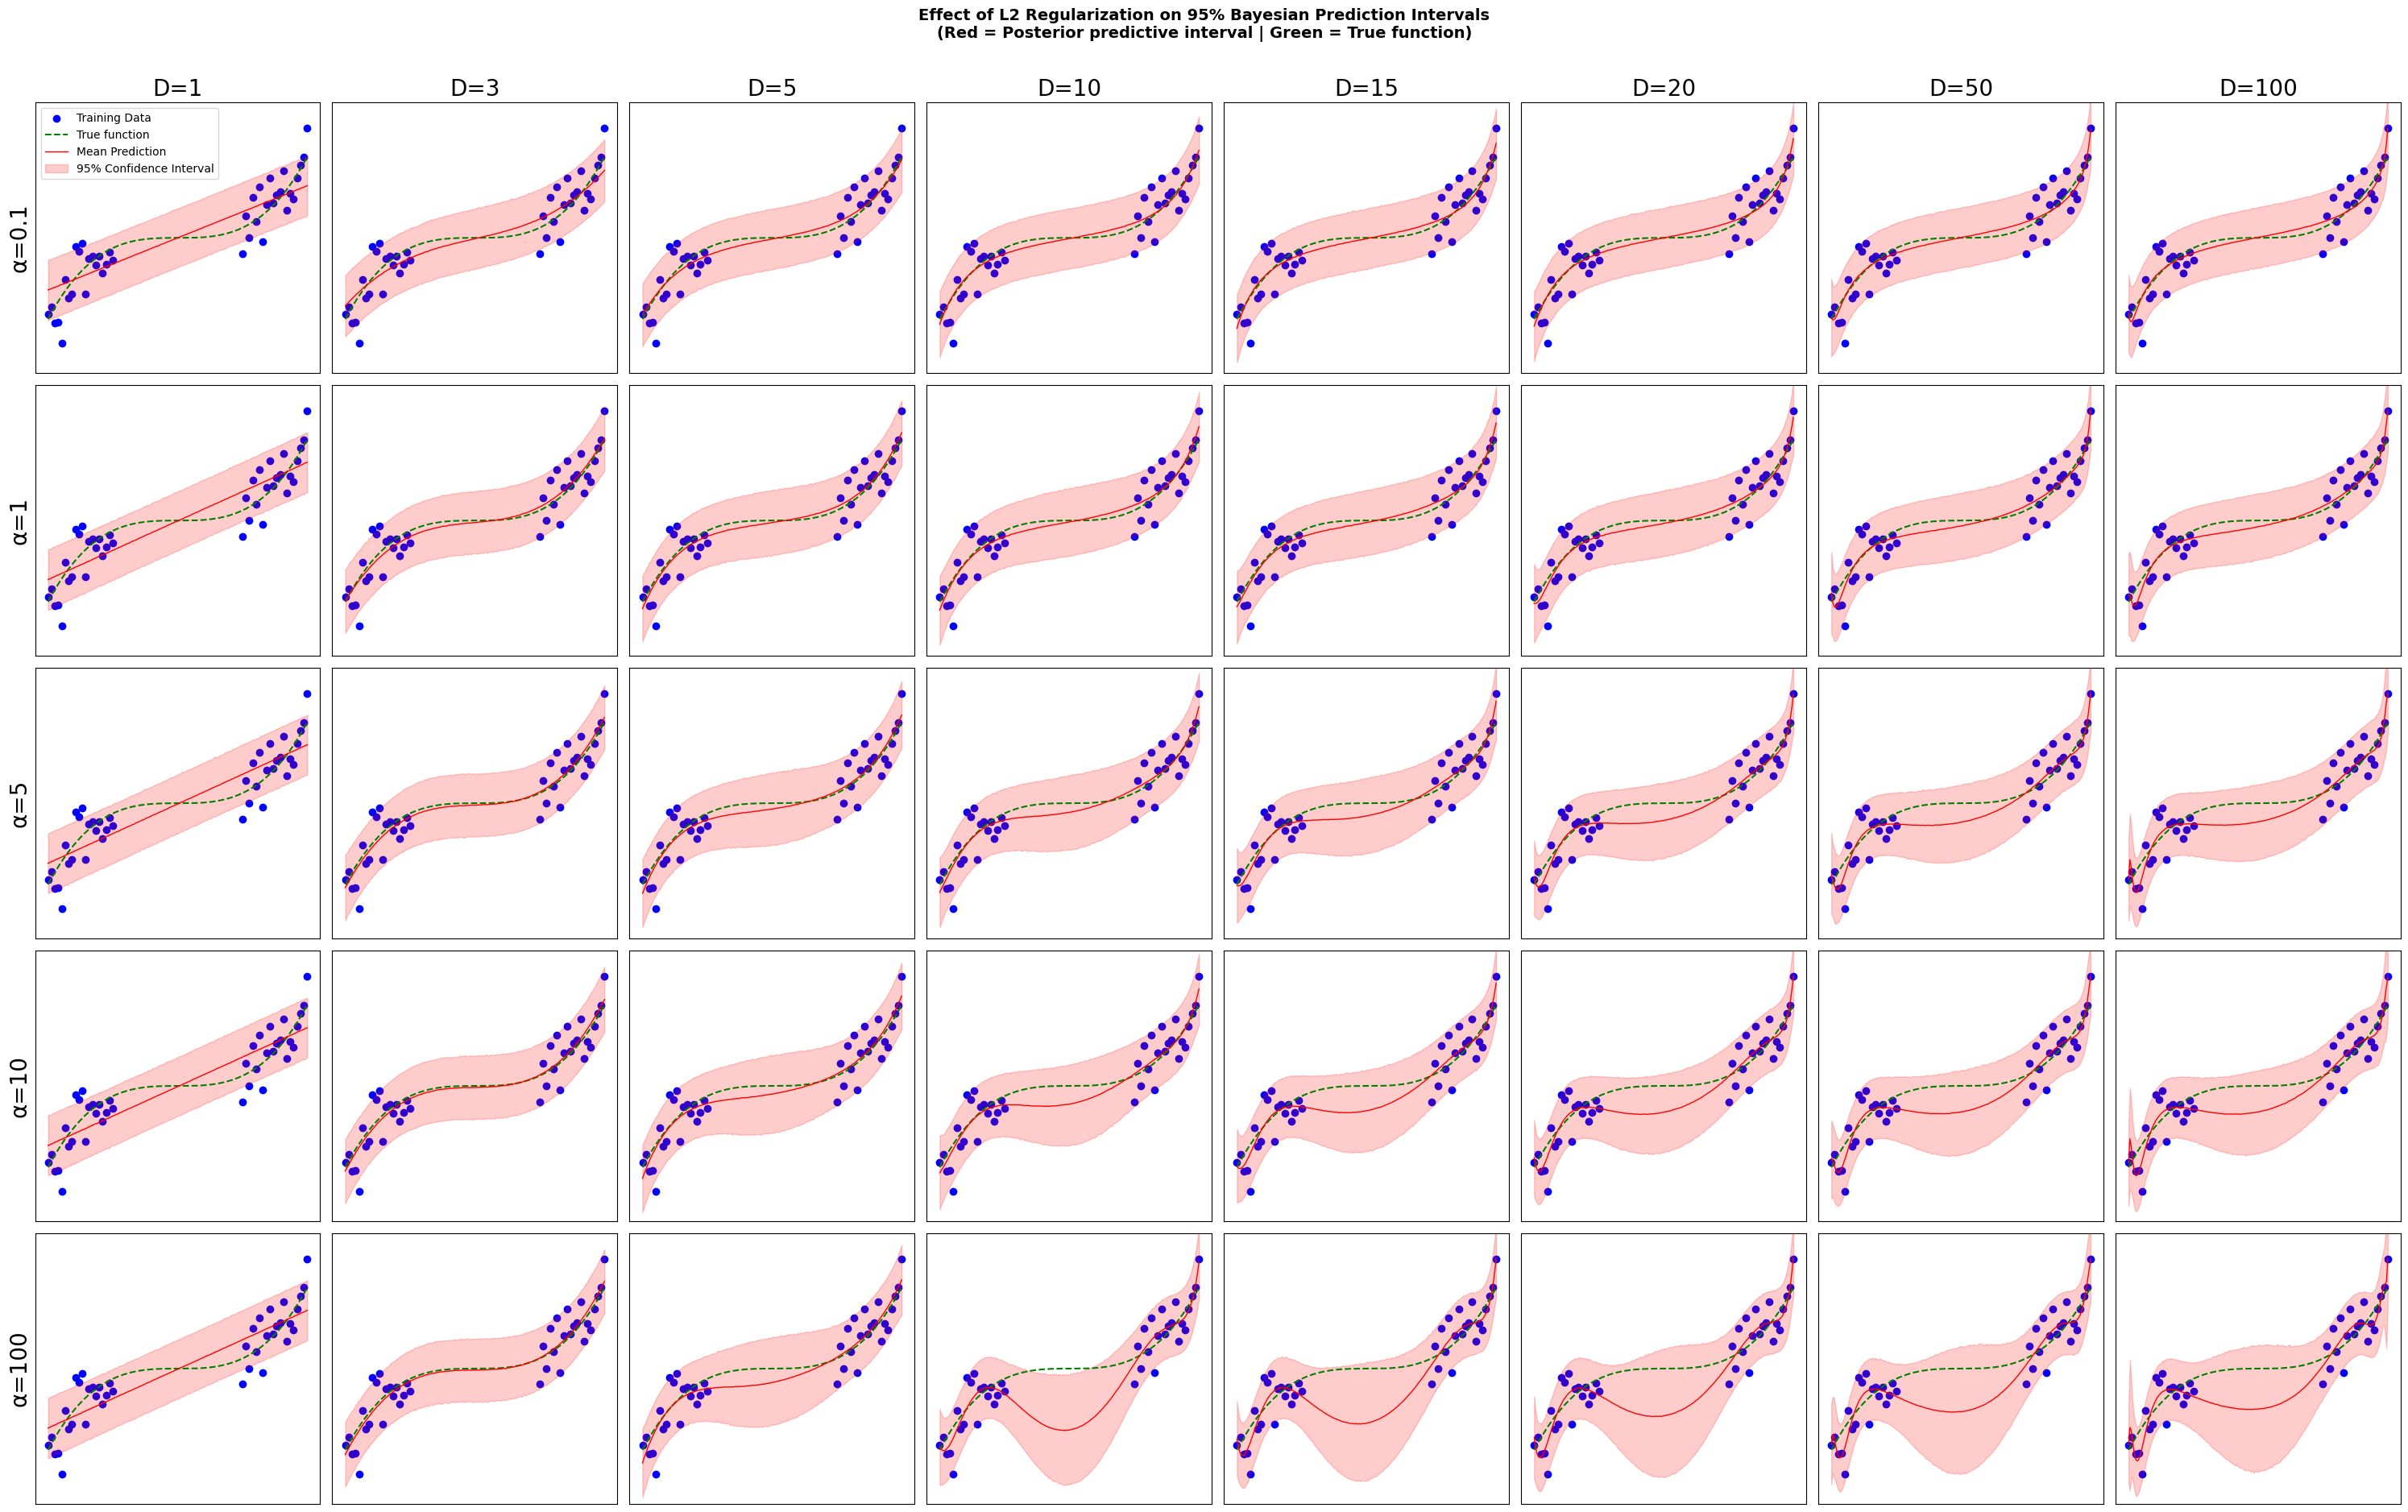

In [9]:
D = [1, 3, 5, 10, 15, 20, 50, 100]
alpha = [0.1, 1, 5, 10, 100]
number_of_points = 20

x_train, y_train, x_test = generate_data(number_of_points=number_of_points)
x_train = x_train[:, np.newaxis]
x_test = x_test[:, np.newaxis]
fig, axes = plt.subplots(len(alpha), len(D), figsize=(30, 18))
for row, a in enumerate(alpha):
    for col, d in enumerate(D):
        #create polynomial features
        poly = PolynomialFeatures(degree=d)
        x_train_poly = poly.fit_transform(x_train)
        x_test_poly = poly.transform(x_test)
        
        #get posterior predictive samples
        _, posterior_predictive_samples = get_posterior_samples(prior_var=a, noise_var=0.3, x_matrix=x_train_poly, y_matrix=y_train, x_test_matrix=x_test_poly, samples=200)
        
        #compute mean and 95% predictive interval
        mean_pred = np.mean(posterior_predictive_samples, axis=0)
        lower = np.percentile(posterior_predictive_samples, 2.5, axis=0)
        upper = np.percentile(posterior_predictive_samples, 97.5, axis=0)
        
        ax = axes[row, col]
        ax.scatter(x_train, y_train, color='blue', label='Training Data')
        ax.plot(x_test, 3 * x_test**3, 'g--', label='True function')
        ax.plot(x_test, mean_pred, color='red', label='Mean Prediction', linewidth=1)
        ax.fill_between(x_test.flatten(), lower, upper, color='red', alpha=0.2, label='95% Confidence Interval')
        ax.set_xlim(-1.1, 1.1)
        ax.set_ylim(-5, 5)
        
        if row == 0:
            ax.set_title(f'D={d}', fontsize=20)
        if col == 0:
            ax.set_ylabel(f'α={a}', fontsize=20)
            
        if row == 0 and col == 0:
            ax.legend()
                
        ax.set_xticks([])
        ax.set_yticks([])
        
plt.tight_layout()
plt.suptitle('Effect of L2 Regularization on 95% Bayesian Prediction Intervals\n(Red = Posterior predictive interval | Green = True function)', y=1.04, fontsize=14, fontweight='bold')
plt.show()

#### **Based on your visualizaion, describe in intuitive terms what is the role of $\alpha$ and $D$ in determining the shape of the posterior predictive uncertainty.**

<div style="background-color: #dde3fb; padding: 20px; border-radius: 5px; color: black;  box-sizing: border-box; width: 100%">

**Role of α (prior variance):**

α controls the variance of the prior distribution on the weights w and determines the strength of regularization in the equivalent Ridge regression formulation, where λ_Ridge = σ²/α, establishing an inverse relationship between α and regularization strength. A smaller α corresponds to a strong, highly informative prior that expresses high confidence that weights should remain close to zero. This constraint encourages smaller weights and smoother functions, resulting in a posterior distribution with lower variance. Consequently, the predictive intervals are narrower, reflecting more confident predictions. Conversely, a larger α corresponds to a weak, vague prior that allows weights to take larger values and enables the model to learn more complex functions. With this weaker constraint, the model exhibits higher posterior variance, leading to wider predictive intervals that reflect greater uncertainty about the predictions.

**Role of D (polynomial degree):**

D controls the complexity of the model by determining the number of polynomial features, which directly impacts the model's capacity to capture non-linear patterns in the data. A smaller D leads to simpler, more rigid models such as straight lines or parabolas that have limited flexibility and may underfit the data. These constrained models exhibit lower variance in their predictions, producing narrower predictive intervals. However, this rigidity can be problematic because small D models dangerously underestimate uncertainty in regions without training data, such as the gap in our dataset. This occurs because all posterior samples converge toward similar shapes due to the limited functional forms available, creating false confidence in regions where the model is actually extrapolating. As D increases, the model becomes increasingly flexible and capable of fitting complex non-linear patterns, allowing it to adapt more closely to the training data. However, this increased flexibility comes at the cost of higher variance, particularly in unobserved regions where different posterior samples can produce vastly different extrapolations. This manifests as wider predictive intervals, especially in the gap region, which better captures the true epistemic uncertainty about predictions in areas where the model lacks information.

**Interaction between D and α:**

We can underline that the impact of α is relatively modest for small values of D, where the limited number of parameters is well-constrained by the available data. However, the effect of α becomes dramatic for large D, where many parameters can vary freely. The combination of high model flexibility from large D with weak regularization from large α produces the widest predictive intervals, as clearly visible in the bottom-right corner of the visualization grid. This interaction demonstrates that both model complexity and prior strength must be considered together when calibrating predictive uncertainty.

</div>

***Hint:*** Read Problem 3 before implementing Problem 2, you can implement both at the same time.
<br><br>
**Extra Credit:** When the feature map $\phi$ is a general (usually non-linear transformation), applying Bayesian linear regression on the transformed input is called **Bayesian Kernel Regression**. Choose your own non-linear feature map $\phi: \mathbb{R} \to \mathbb{R}^5$ and visualize the 95% posterior predictive interval of the Bayesian kernel regression for your choice of $\phi$ and $D = [1,3,5,10,15,20,50,100]$, $\alpha = [0.1, 1, 5, 10, 100]$. Compare the visualization to the that for Bayesian polynomial regression. Does the posterior predictive of your Bayesian kernel regression capture important properties of the posterior predictive of the Bayesian polynomial regression model?
<br><br>
**Note:** we highly recommend that you implement the following feature map:
<br><br>
\begin{align}
\phi: \mathbb{R}^{D'} &\to \mathbb{R}^D\\
\mathbf{x} &\mapsto \left[\sqrt{\frac{2}{D}} \cos(w_1^\top x + b_1), \ldots, \sqrt{\frac{2}{D}} \cos(w_D^\top x + b_D)\right]
\end{align}
<br>where $b_d \sim [0, 2\pi]$ and $w_d \sim N(0, \beta I_{D'\times D'})$ need to be randomly sampled and fixed before modeling and inference. For this exercise, we suggest setting $\beta=10$. The features generated by $\phi$ are called **Random Fourier Features**. As the number of features $D$ tends to infinity, the resulting Bayesian kernel regression model tends to an important type of Bayesian (nonparametric) model called Gaussian Process model. We will revisit the connection between Bayesian kernel regression and Gaussian processes in the latter part of the course.

#### **Extra credit: Random Fourier Features**

Log-likelihood range: [-45.46, -26.85]


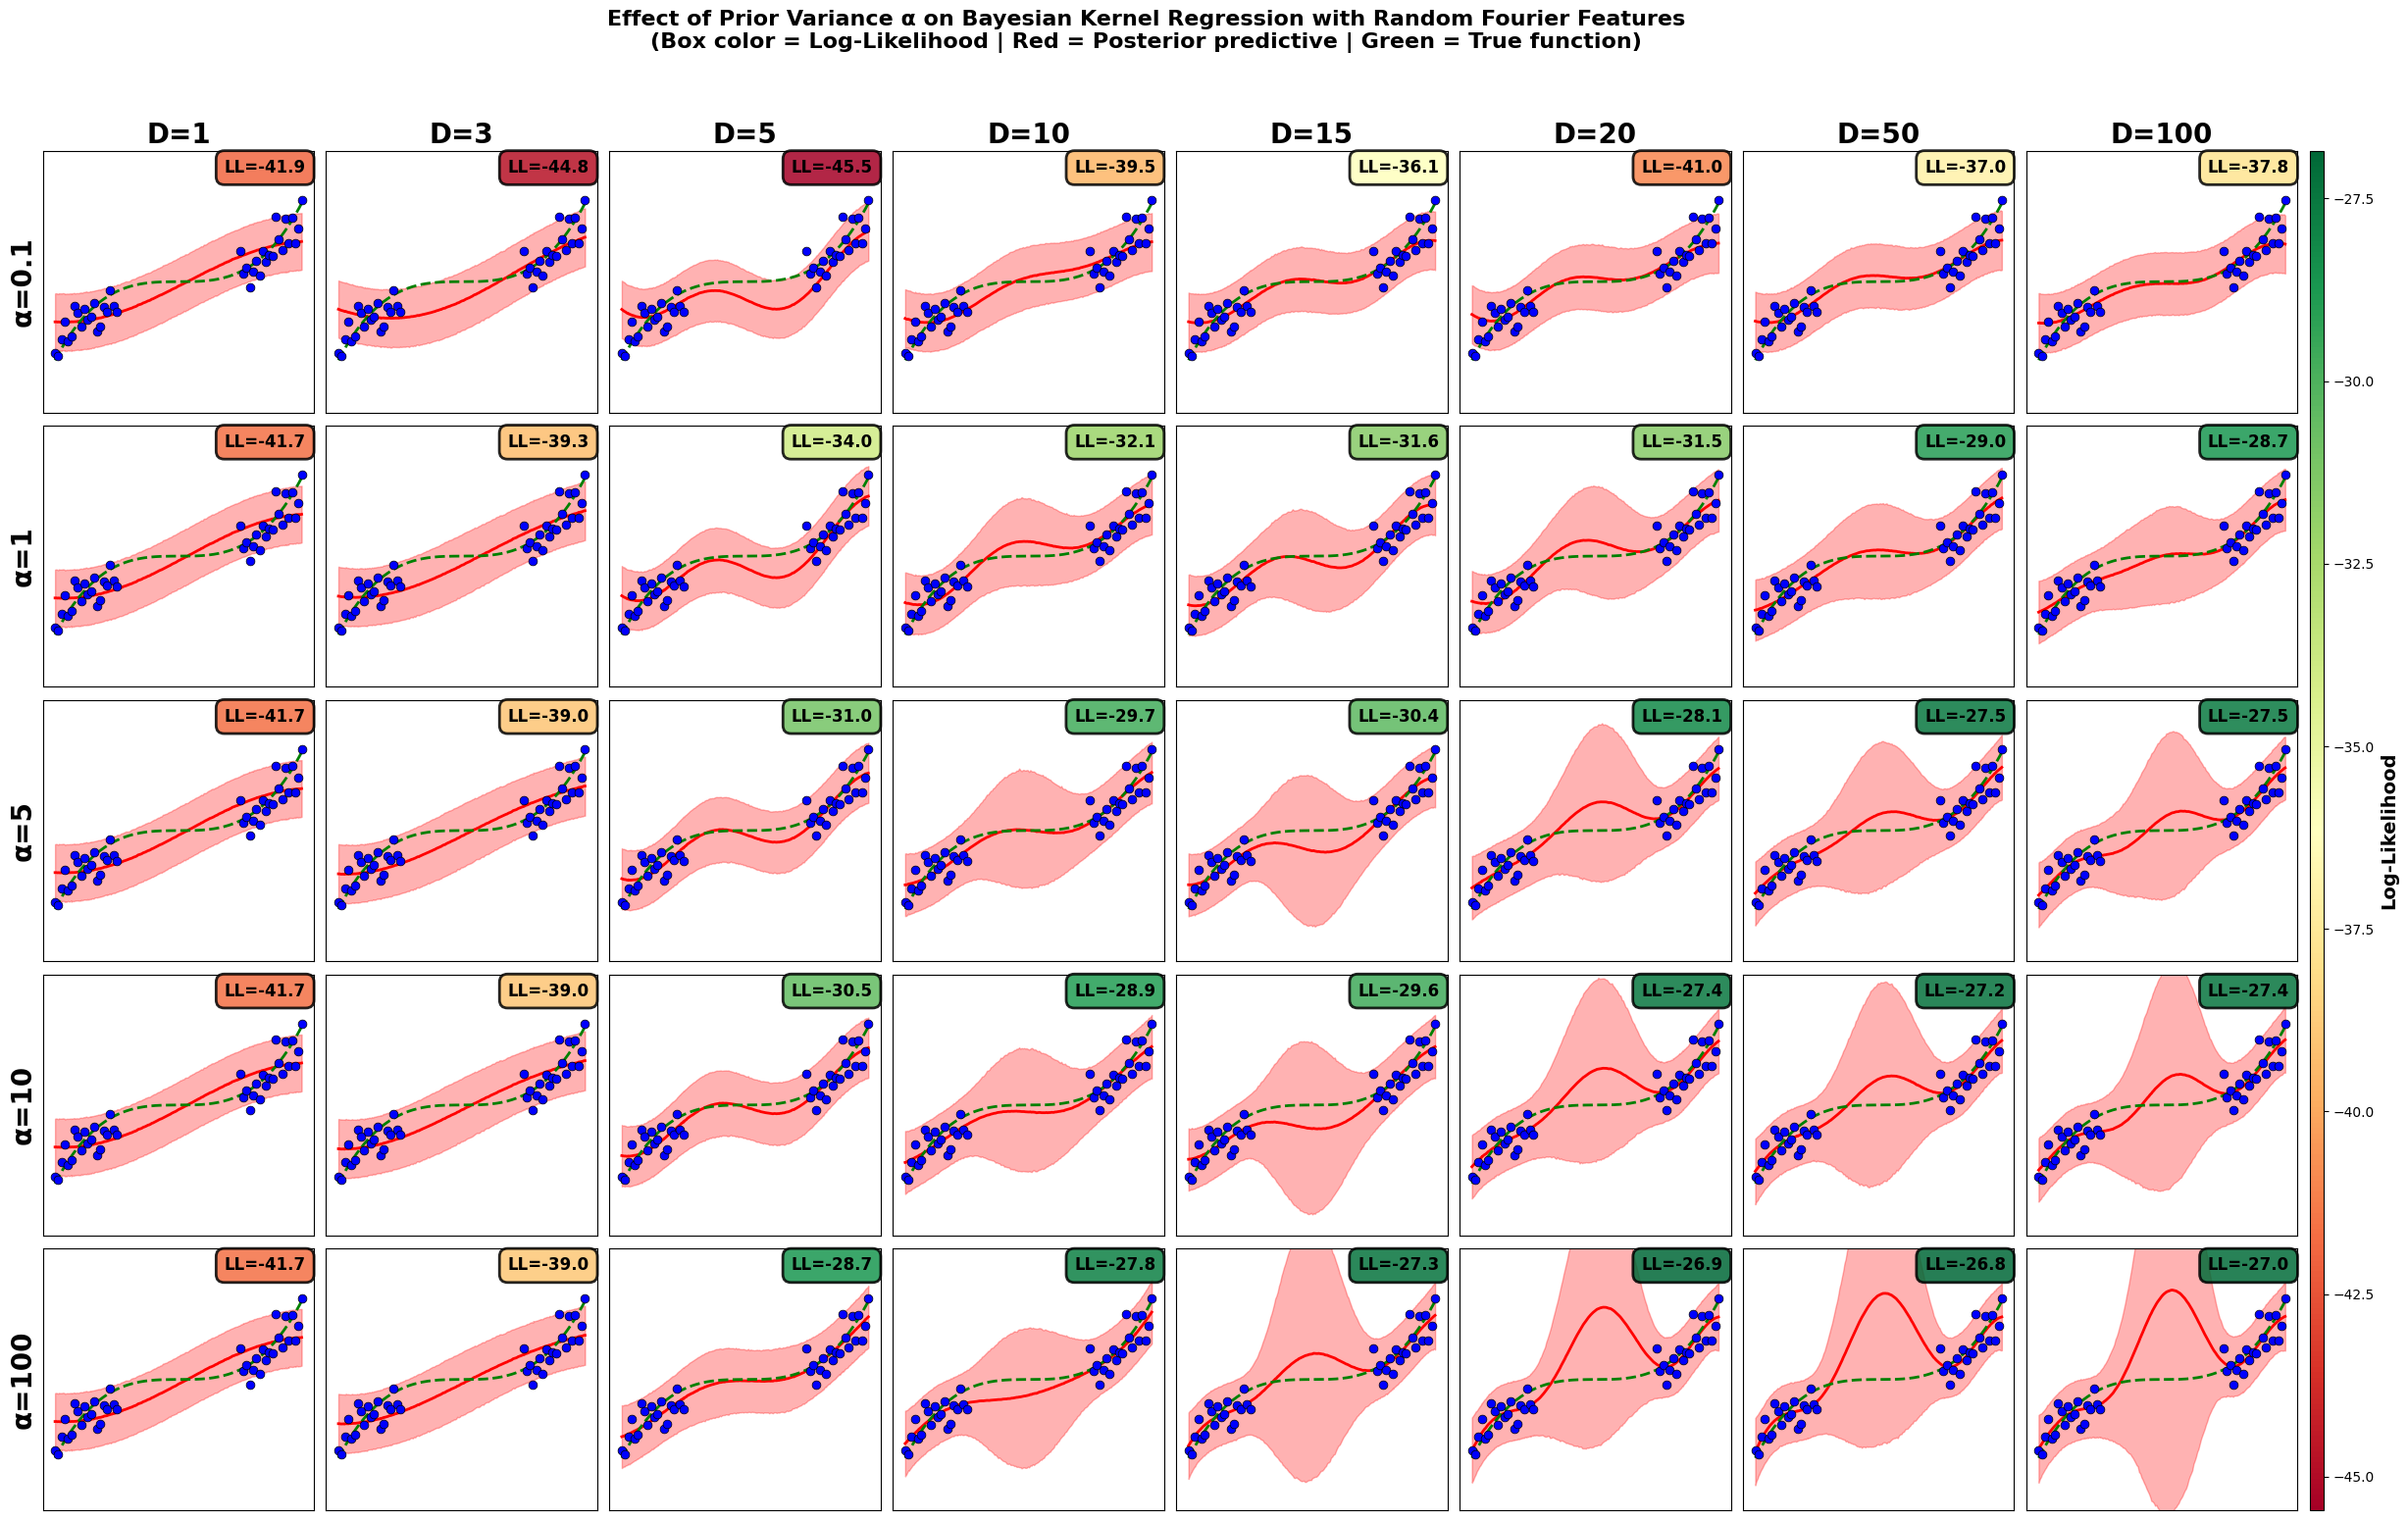

In [10]:
from matplotlib.colors import Normalize
from scipy.stats import norm
import matplotlib.cm as cm

def create_rff_features(x, D, beta=10, seed=None):
    """
    Create Random Fourier Features.
    
    Args:
        x: input data (n_samples, 1)
        D: number of features
        beta: variance parameter for w
        seed: random seed for reproducibility
    
    Returns:
        phi_x: RFF features (n_samples, D)
        w, b: parameters (to reuse for test set)
    """
    if seed is not None:
        np.random.seed(seed)
    
    #sample w and b ONCE and fix them
    w = np.random.normal(0, np.sqrt(beta), size=D)
    b = np.random.uniform(0, 2*np.pi, size=D)
    
    #compute features: sqrt(2/D) * cos(w*x + b)
    phi_x = np.sqrt(2/D) * np.cos(x @ w.reshape(1, -1) + b)
    
    return phi_x, w, b


def compute_log_likelihood_rff(x_train_rff, y_train, mu_N, Sigma_N, noise_var):
    log_likelihood = 0.0
    for i in range(len(y_train)):
        x_m = x_train_rff[i]
        y_m = y_train[i]
        pred_mean = mu_N.T @ x_m
        pred_var = noise_var + x_m.T @ Sigma_N @ x_m
        pred_std = np.sqrt(pred_var)
        log_prob = norm.logpdf(y_m, loc=pred_mean, scale=pred_std)
        log_likelihood += log_prob
    return log_likelihood


D = [1, 3, 5, 10, 15, 20, 50, 100]
alpha = [0.1, 1, 5, 10, 100]
number_of_points = 20
noise_var = 0.3

np.random.seed(42)
x_train, y_train, x_test = generate_data(number_of_points=number_of_points, noise_variance=noise_var)
x_train = x_train[:, np.newaxis]
x_test = x_test[:, np.newaxis]

log_likelihoods_rff = np.zeros((len(alpha), len(D)))

#compute all log-likelihoods
for row, a in enumerate(alpha):
    for col, d in enumerate(D):
        x_train_rff, w_rff, b_rff = create_rff_features(x_train, D=d, beta=10, seed=42)
        
        prior_cov = a * np.eye(x_train_rff.shape[1])
        precision_prior = np.linalg.inv(prior_cov)
        precision_likelihood = (1 / noise_var) * (x_train_rff.T @ x_train_rff)
        
        Sigma_N = np.linalg.inv(precision_prior + precision_likelihood)
        mu_N = (1 / noise_var) * Sigma_N @ x_train_rff.T @ y_train
        
        ll = compute_log_likelihood_rff(x_train_rff, y_train, mu_N, Sigma_N, noise_var)
        log_likelihoods_rff[row, col] = ll

print(f"Log-likelihood range: [{log_likelihoods_rff.min():.2f}, {log_likelihoods_rff.max():.2f}]")

norm_color = Normalize(vmin=log_likelihoods_rff.min(), vmax=log_likelihoods_rff.max())
cmap = plt.colormaps['RdYlGn']

fig = plt.figure(figsize=(30, 18))
gs = fig.add_gridspec(len(alpha), len(D) + 1, width_ratios=[1]*len(D) + [0.05], wspace=0.05, hspace=0.05)

for row, a in enumerate(alpha):
    for col, d in enumerate(D):
        x_train_rff, w_rff, b_rff = create_rff_features(x_train, D=d, beta=10, seed=42)
        x_test_rff = np.sqrt(2/d) * np.cos(x_test @ w_rff.reshape(1, -1) + b_rff)
        
        _, posterior_predictive_samples = get_posterior_samples(
            prior_var=a, noise_var=noise_var, x_matrix=x_train_rff, 
            y_matrix=y_train, x_test_matrix=x_test_rff, samples=200
        )
        
        mean_pred = np.mean(posterior_predictive_samples, axis=0)
        lower = np.percentile(posterior_predictive_samples, 2.5, axis=0)
        upper = np.percentile(posterior_predictive_samples, 97.5, axis=0)
        
        ll = log_likelihoods_rff[row, col]
        
        ax = fig.add_subplot(gs[row, col])
        ax.scatter(x_train, y_train, color='blue', s=40, zorder=5, edgecolors='black', linewidths=0.5)
        ax.plot(x_test, 3 * x_test**3, 'g--', linewidth=2, zorder=4)
        ax.plot(x_test, mean_pred, color='red', linewidth=2, zorder=3)
        ax.fill_between(x_test.flatten(), lower, upper, color='red', alpha=0.3, zorder=2)
        
        ax.set_xlim(-1.1, 1.1)
        ax.set_ylim(-5, 5)
        
        textstr = f'LL={ll:.1f}'
        box_color = cmap(norm_color(ll))
        props = dict(boxstyle='round,pad=0.5', facecolor=box_color, alpha=0.85, edgecolor='black', linewidth=2)
        ax.text(0.97, 0.97, textstr, transform=ax.transAxes, fontsize=12,
                verticalalignment='top', horizontalalignment='right', bbox=props, fontweight='bold')
        
        if row == 0:
            ax.set_title(f'D={d}', fontsize=20, fontweight='bold')
        if col == 0:
            ax.set_ylabel(f'α={a}', fontsize=20, fontweight='bold')
        
        ax.set_xticks([])
        ax.set_yticks([])

cbar_ax = fig.add_subplot(gs[:, -1])
cbar = fig.colorbar(cm.ScalarMappable(norm=norm_color, cmap=cmap), cax=cbar_ax)
cbar.set_label('Log-Likelihood', fontsize=14, fontweight='bold')

plt.suptitle('Effect of Prior Variance α on Bayesian Kernel Regression with Random Fourier Features\n(Box color = Log-Likelihood | Red = Posterior predictive | Green = True function)', y=0.96, fontsize=16, fontweight='bold')
plt.show()

#### **Compare the visualization to the that for Bayesian polynomial regression. Does the posterior predictive of your Bayesian kernel regression capture important properties of the posterior predictive of the Bayesian polynomial regression model?**

<div style="background-color: #dde3fb; padding: 20px; border-radius: 5px; color: black;  box-sizing: border-box; width: 100%">

**1. Epistemic uncertainty in the gap region:**

The RFF model better captures epistemic uncertainty in the gap [-0.5, 0.5] compared to polynomial regression. For low-degree polynomials (D=1, 3, 5), the RFF models are dangerously overconfident in the gap, with narrow predictive intervals despite having no training data there. In contrast, polynomial models maintain wider, more realistic uncertainty estimates in this extrapolation region for low D values. However, RFF models are better at capturing the increase in uncertainty as D increases, showing a more pronounced widening of intervals in the gap for higher D, which is a desirable property under covariate shift.

**2. Effect of α (regularization strength):**

Both methods show the expected pattern where larger α (weaker regularization) leads to wider predictive intervals. However, this effect is more pronounced in the RFF model across large D their functional form. This suggests RFF provides more consistent Bayesian uncertainty quantification across large model complexities.

**3. Effect of D (model complexity):**

This is where the key difference emerges. For low to moderate D (1-50), both methods behave similarly, with increasing uncertainty as D grows. However, for very high D (100) combined with large α (100):

- **Polynomial regression:** Maintains stable, well-centered predictions. The mean prediction (red line) still closely follows the true cubic function, even in the gap, with LL=-26.4.
- **RFF:** The mean prediction starts to deviate significantly from the true function, particularly in the gap region where the red line no longer follows the cubic pattern and exhibits erratic behavior. Performance degrades with LL=-26.8

This suggests that RFF is optimal for moderate model complexity (D=20-50) but becomes unstable for very high D, whereas polynomial regression remains robust even at D=100.

**4. Log-likelihood comparison:**

- **Polynomial range:** -36 to -26.4 (optimal: α=100, D=20, LL=-26.4)
- **RFF range:** -45.5 to -26.8 (optimal: α=100, D=50, LL=-26.8)

Polynomial regression achieves the best overall log-likelihood but not from far, and shows superior performance for low D values. RFF reaches near-optimal performance at lower D (D=50), but its performance degrades for D=100 like polynomial regression. The wider LL range for RFF (-45.5 to -26.8 vs -36 to -26.4) indicates higher sensitivity to hyperparameter choices and less robust behavior.

**5. Overall assessment:**

Random Fourier Features successfully capture epistemic uncertainty in the gap for moderate model complexities (D=20-50), providing a good balance between uncertainty quantification and predictive accuracy. However, RFF shows a critical limitation: it degrades for very high D where the mean predictions deviate from the true function, particularly in extrapolation regions. In contrast, polynomial regression maintains stable, well-centered predictions even at D=100. For this dataset, polynomial regression is more robust across the full range of D values, while RFF is best suited for moderate complexity models where it can match polynomial performance with fewer parameters.

</div>

3. **(Model Evaluation and Uncertainty Estimation)** Remember that a direct visual comparision of the 95% predictive interval against the training data is impractical! Rather, to evaluate the fit of the Bayesian model on the observed data, we evaluate the marginal log-likelihood of the data under the posterior. Given a test set $\{(\mathbf{x}^*_m, \mathbf{y}^*_m)\}$, the log posterior predictive likelihood or, simply, the **log-likelihood** is computed as:
\begin{align}
\\ \log \prod_{m=1}^M p(\mathbf{y}^*_m | \mathbf{x}^*_m, \text{Data}) &= \sum_{m=1}^M \log p(\mathbf{y}^*_m | \mathbf{x}^*_m, \text{Data})\\
&= \sum_{m=1}^M \log \int_\mathbf{w} p(\mathbf{y}^*_m | \mathbf{x}^*_m, \mathbf{w}) p(\mathbf{w}| \text{Data}) d\mathbf{w}
\end{align}
<br>i.e. the log-likelihood at a single observation $(\mathbf{x}^*_m, \mathbf{y}^*_m)$ is the log of the likelihood of the observation ***averaged over all models in the posterior***.
<br><br>
For Bayesian linear regression, with posterior ${N}(\mu_N, \Sigma_N)$ we have that
$$
p(y^*_m | x^*_m, \text{Data}) = {N}(\mu^\top\mathbf{x}^*_m, \sigma^2 + (\mathbf{x}^*_m)^\top\Sigma_N\mathbf{x}^*_m)
$$
where $\sigma^2$ is the variance of the observation noise.
<br><br>
For each choice of $D$ and $\alpha$ in Problem 2, compute the log-likelihood of the training data. Examine a models with the higher log-likelihoods and a few with lower log-likelihoods, what is the relationship between log-likelihood and predictive uncertainty? In particular, does a higher log-likelihood indicate "better" predictive uncertainty?

Log-likelihood range: [-35.95, -26.41]


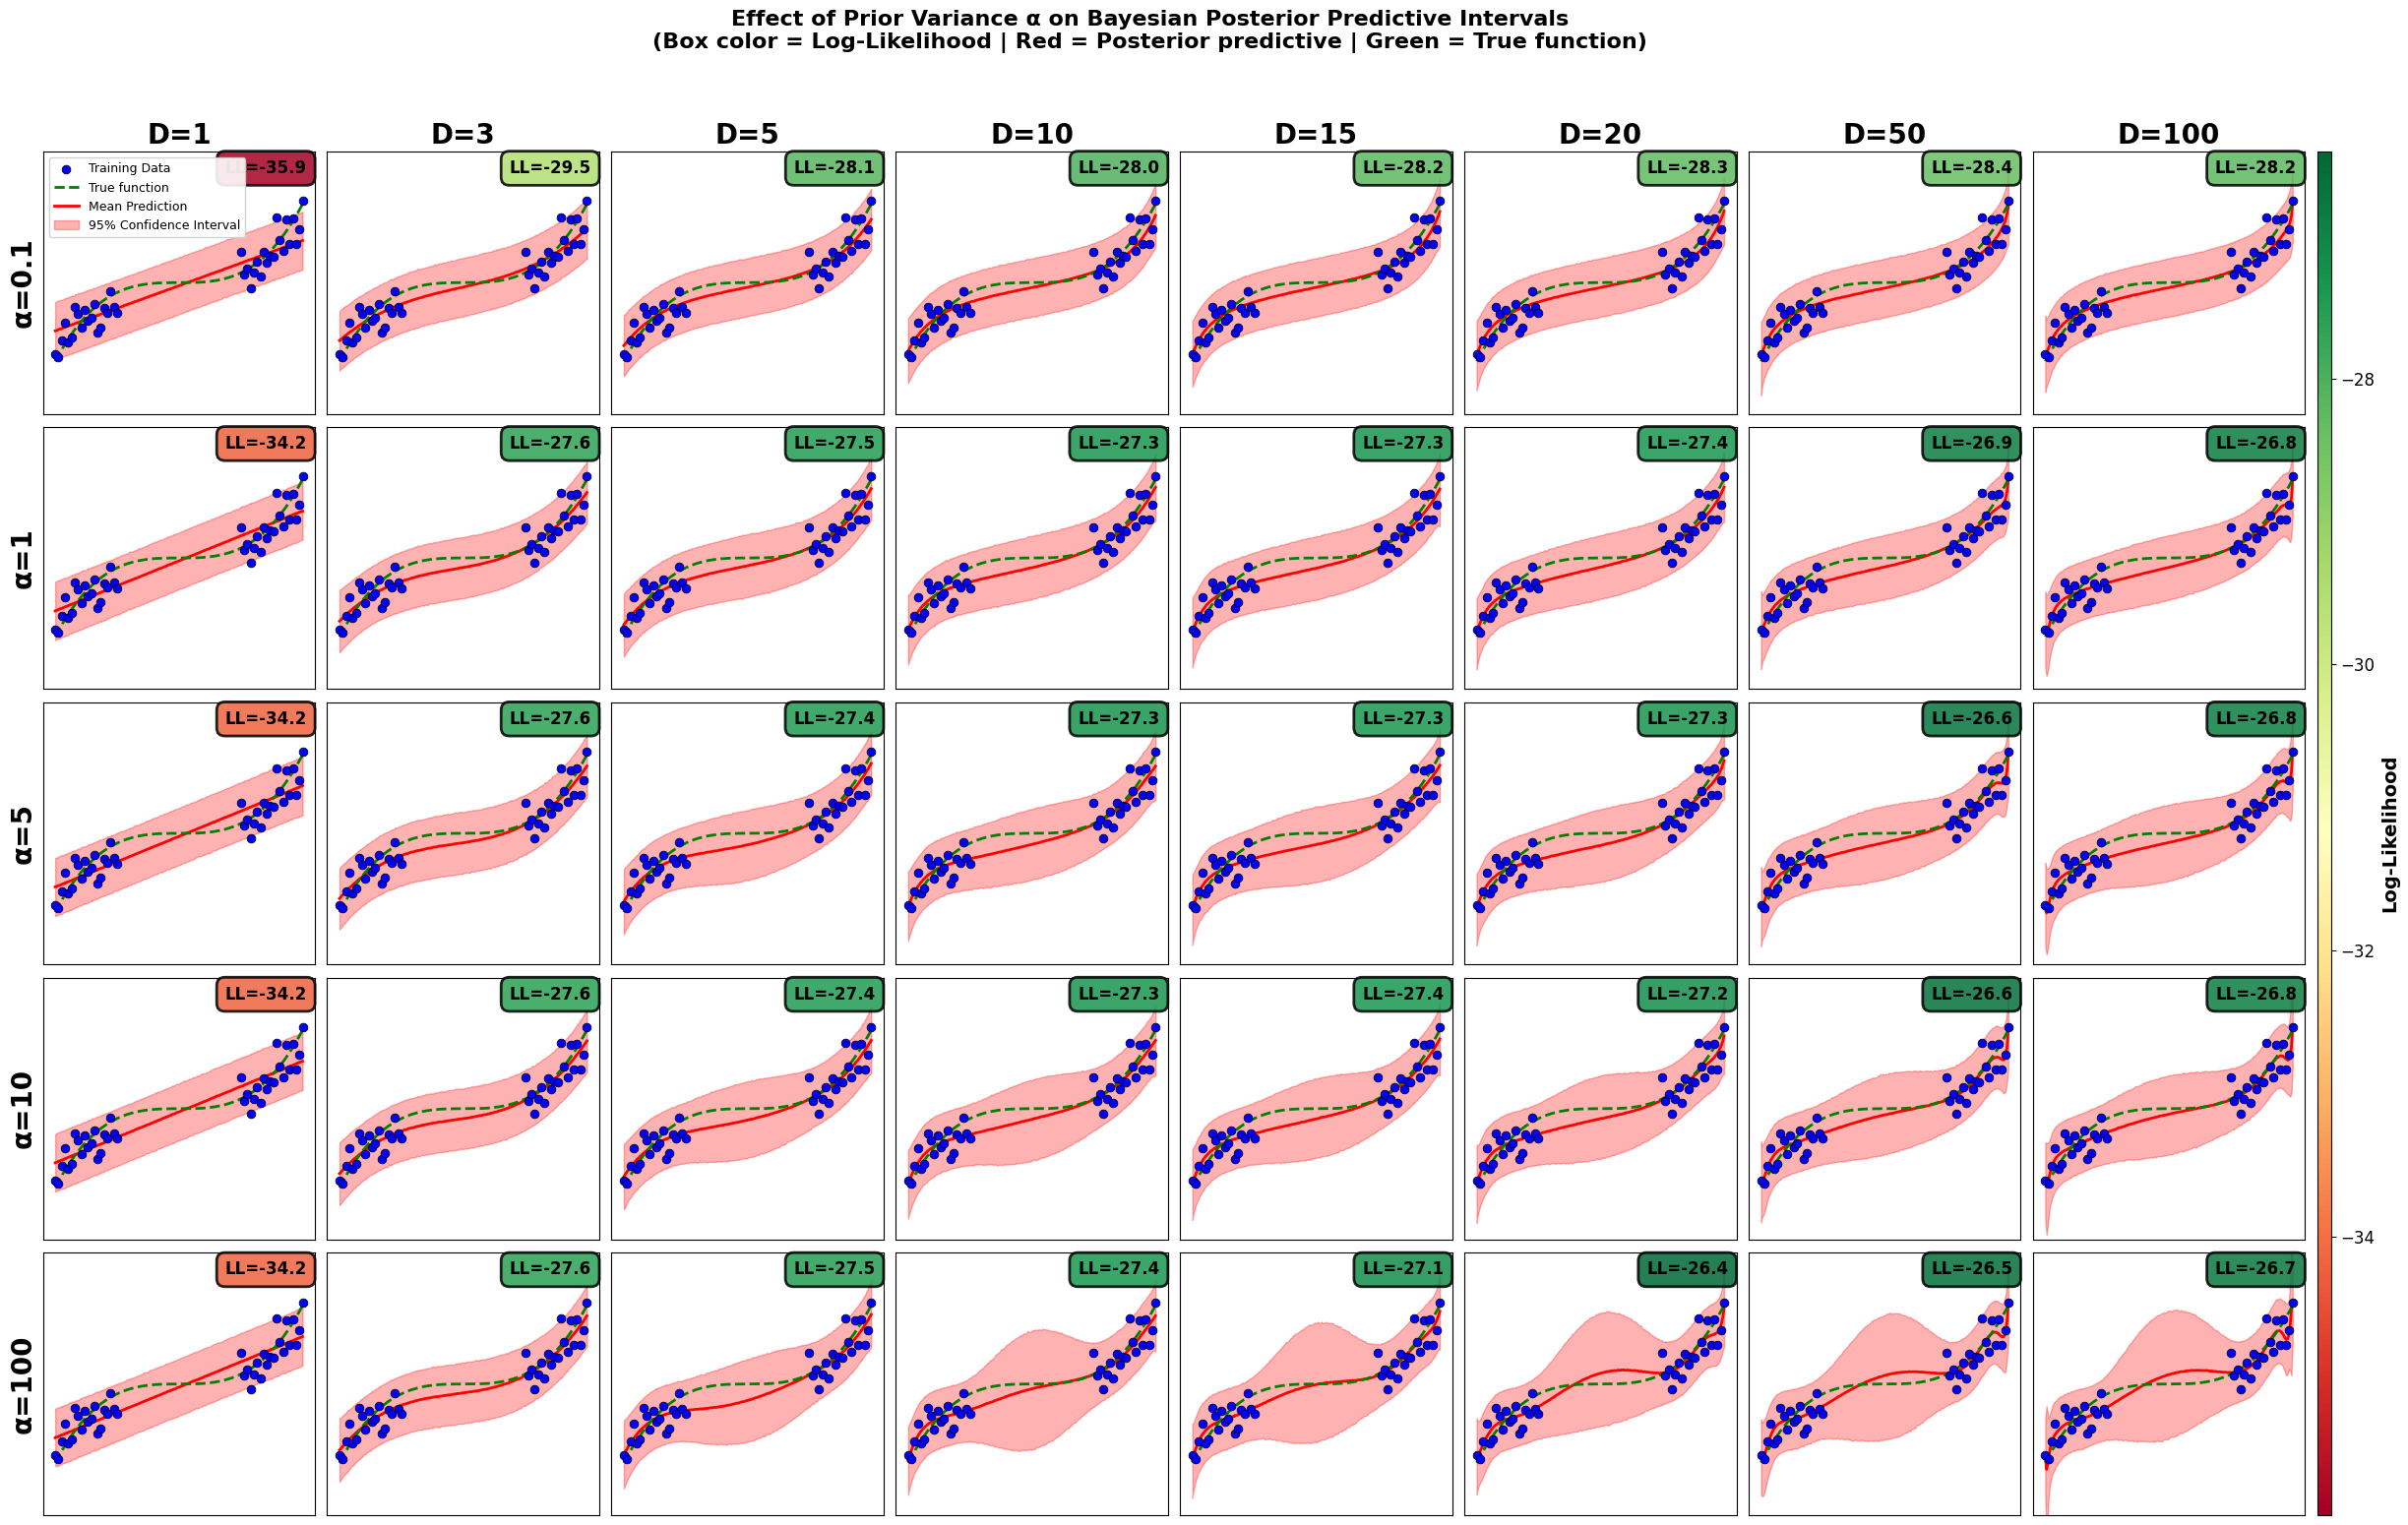

In [11]:
from matplotlib.colors import Normalize
import matplotlib.cm as cm
from sklearn.preprocessing import PolynomialFeatures
from scipy.stats import norm

def compute_log_likelihood(x_train_poly, y_train, mu_N, Sigma_N, noise_var):
    """
    Compute log-likelihood of training data under posterior predictive distribution.
    
    For each training point (x_m, y_m):
    p(y_m | x_m, Data) = N(μ_N^T x_m, σ² + x_m^T Σ_N x_m)
    
    Returns:
        log_likelihood: sum of log probabilities
    """
    log_likelihood = 0.0
    
    for i in range(len(y_train)):
        x_m = x_train_poly[i]
        y_m = y_train[i]
        
        # Posterior predictive mean: μ_N^T x_m
        pred_mean = mu_N.T @ x_m
        
        # Posterior predictive variance: σ² + x_m^T Σ_N x_m
        pred_var = noise_var + x_m.T @ Sigma_N @ x_m
        pred_std = np.sqrt(pred_var)
        
        # Log probability under Gaussian
        log_prob = norm.logpdf(y_m, loc=pred_mean, scale=pred_std)
        log_likelihood += log_prob
    
    return log_likelihood

D = [1, 3, 5, 10, 15, 20, 50, 100]
alpha = [0.1, 1, 5, 10, 100]
number_of_points = 20
noise_var = 0.3

# generate data once
np.random.seed(42)
x_train, y_train, x_test = generate_data(number_of_points=number_of_points, noise_variance=noise_var)
x_train = x_train[:, np.newaxis]
x_test = x_test[:, np.newaxis]

log_likelihoods = np.zeros((len(alpha), len(D)))

#compute all log-likelihoods
for row, a in enumerate(alpha):
    for col, d in enumerate(D):
        #create polynomial features
        poly = PolynomialFeatures(degree=d, include_bias=True)
        x_train_poly = poly.fit_transform(x_train)
        
        #prior: w ~ N(0, α*I)
        prior_cov = a * np.eye(x_train_poly.shape[1])
        
        # posterior: N(μ_N, Σ_N)
        precision_prior = np.linalg.inv(prior_cov)
        precision_likelihood = (1 / noise_var) * (x_train_poly.T @ x_train_poly)
        
        Sigma_N = np.linalg.inv(precision_prior + precision_likelihood)
        mu_N = (1 / noise_var) * Sigma_N @ x_train_poly.T @ y_train
        
        ll = compute_log_likelihood(x_train_poly, y_train, mu_N, Sigma_N, noise_var)
        log_likelihoods[row, col] = ll

print(f"Log-likelihood range: [{log_likelihoods.min():.2f}, {log_likelihoods.max():.2f}]")

norm_color = Normalize(vmin=log_likelihoods.min(), vmax=log_likelihoods.max())
cmap = plt.colormaps['RdYlGn']  # Red (bad) -> Yellow -> Green (good)

#second pass: create visualization
fig = plt.figure(figsize=(30, 18))
gs = fig.add_gridspec(len(alpha), len(D) + 1, width_ratios=[1]*len(D) + [0.05], wspace=0.05, hspace=0.05)

for row, a in enumerate(alpha):
    for col, d in enumerate(D):
        poly = PolynomialFeatures(degree=d, include_bias=True)
        x_train_poly = poly.fit_transform(x_train)
        x_test_poly = poly.transform(x_test)
        
        _, posterior_predictive_samples = get_posterior_samples(
            prior_var=a, 
            noise_var=noise_var, 
            x_matrix=x_train_poly, 
            y_matrix=y_train, 
            x_test_matrix=x_test_poly, 
            samples=200
        )
        
        #compute mean and 95% predictive interval
        mean_pred = np.mean(posterior_predictive_samples, axis=0)
        lower = np.percentile(posterior_predictive_samples, 2.5, axis=0)
        upper = np.percentile(posterior_predictive_samples, 97.5, axis=0)
        
        #get log-likelihood for this configuration
        ll = log_likelihoods[row, col]
        
        ax = fig.add_subplot(gs[row, col])
        
        ax.scatter(x_train, y_train, color='blue', s=40, label='Training Data', zorder=5, edgecolors='black', linewidths=0.5)
        ax.plot(x_test, 3 * x_test**3, 'g--', label='True function', linewidth=2, zorder=4)
        ax.plot(x_test, mean_pred, color='red', label='Mean Prediction', linewidth=2, zorder=3)
        ax.fill_between(x_test.flatten(), lower, upper, color='red', alpha=0.3, label='95% Confidence Interval', zorder=2)
        
        ax.set_xlim(-1.1, 1.1)
        ax.set_ylim(-5, 5)
        
        textstr = f'LL={ll:.1f}'
        box_color = cmap(norm_color(ll))
        props = dict(
            boxstyle='round,pad=0.5', 
            facecolor=box_color,
            alpha=0.85,
            edgecolor='black', 
            linewidth=2
        )
        
        ax.text(0.97, 0.97, textstr, transform=ax.transAxes, fontsize=12,
                verticalalignment='top', horizontalalignment='right', 
                bbox=props, fontweight='bold', color='black')
        
        if row == 0:
            ax.set_title(f'D={d}', fontsize=20, fontweight='bold')
        if col == 0:
            ax.set_ylabel(f'α={a}', fontsize=20, fontweight='bold')
            
        if row == 0 and col == 0:
            ax.legend(loc='upper left', fontsize=9, framealpha=0.9)
                
        ax.set_xticks([])
        ax.set_yticks([])

cbar_ax = fig.add_subplot(gs[:, -1])
cbar = fig.colorbar(cm.ScalarMappable(norm=norm_color, cmap=cmap), cax=cbar_ax)
cbar.set_label('Log-Likelihood', fontsize=14, fontweight='bold')
cbar.ax.tick_params(labelsize=12)

plt.suptitle('Effect of Prior Variance α on Bayesian Posterior Predictive Intervals\n(Box color = Log-Likelihood | Red = Posterior predictive | Green = True function)', y=0.96, fontsize=16, fontweight='bold')
plt.show()


#### **Examine a models with the higher log-likelihoods and a few with lower log-likelihoods, what is the relationship between log-likelihood and predictive uncertainty?**

<div style="background-color: #dde3fb; padding: 20px; border-radius: 5px; color: black;  box-sizing: border-box; width: 100%">

The worst log-likelihoods are observed for D=1 and alpha=0.1 with LL=-35.9, which corresponds to a very simple model with a strong prior that severely underfits the data. The predictive intervals for this model are narrow and do not capture the true function well, because the model is linear and cannot capture the non-linear patterns in the data. This results in a poor fit and low log-likelihood.
The best log-likelihoods are observed for D=20 and alpha=100 with LL=-26.4, which corresponds to a more complex model with a weak prior that allows for greater flexibility. The predictive intervals for this model are wider and better capture the true function, especially in the gap region where there is no training data. This model achieves a good balance between fitting the data and capturing uncertainty, resulting in a high log-likelihood.

</div>

#### **In particular, does a higher log-likelihood indicate "better" predictive uncertainty?**

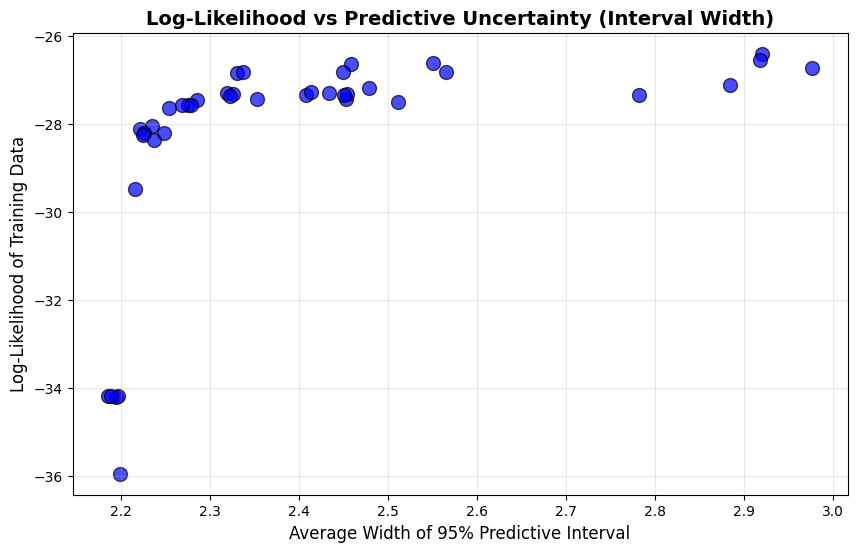

In [12]:
#graph log likelihood as a function of predictive uncertainty (width of the 95% interval)
interval_widths = np.zeros((len(alpha), len(D)))
for row, a in enumerate(alpha):
    for col, d in enumerate(D):
        #create polynomial features
        poly = PolynomialFeatures(degree=d, include_bias=True)
        x_train_poly = poly.fit_transform(x_train)
        x_test_poly = poly.transform(x_test)
        
        _, posterior_predictive_samples = get_posterior_samples(
            prior_var=a, 
            noise_var=noise_var, 
            x_matrix=x_train_poly, 
            y_matrix=y_train, 
            x_test_matrix=x_test_poly, 
            samples=200
        )
        
        lower = np.percentile(posterior_predictive_samples, 2.5, axis=0)
        upper = np.percentile(posterior_predictive_samples, 97.5, axis=0)
        interval_widths[row, col] = np.mean(upper - lower)
        
# flatten arrays for plotting
log_likelihoods_flat = log_likelihoods.flatten()
interval_widths_flat = interval_widths.flatten()

plt.figure(figsize=(10, 6))
plt.scatter(interval_widths_flat, log_likelihoods_flat, color='blue', s=100, edgecolors='black', alpha=0.7)
plt.xlabel('Average Width of 95% Predictive Interval', fontsize=12)
plt.ylabel('Log-Likelihood of Training Data', fontsize=12)
plt.title('Log-Likelihood vs Predictive Uncertainty (Interval Width)', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.show()

<div style="background-color: #dde3fb; padding: 20px; border-radius: 5px; color: black;  box-sizing: border-box; width: 100%"

This scatter plot reveals two distinct regimes:

**Poor calibration regime** (bottom-left cluster) with models with narrow predictive intervals (width < 2.3) achieve poor log-likelihood (LL < -30). These configurations correspond to overconfident models (small α, small D) that underestimate uncertainty while fitting the data poorly.

**Well-calibrated regime** (upper cluster)with models with wider predictive intervals (width > 2.3) achieve substantially better log-likelihood (LL ≈ -26.5 to -28). This demonstrates that appropriate uncertainty quantification is correlated with better predictive performance.

Within the well-calibrated regime, there is a sweet spot around width 2.4-2.7 where log-likelihood is maximized, suggesting an optimal balance between model flexibility and uncertainty estimation. Beyond this range, further increasing interval width does not significantly improve performance, indicating a plateau.

The positive correlation between predictive interval width and log-likelihood demonstrates that models with appropriately wide intervals (capturing epistemic uncertainty) also achieve better performance. Conversely, models that are falsely confident with narrow intervals perform poorly. Well-calibrated Bayesian models naturally achieve both appropriate uncertainty quantification and good predictive performance.

However, it is important to note that while there is a general trend of higher log-likelihoods being associated with better predictive uncertainty, we need to be cautious. In fact, loglikelihood mesures model adequation to observed data but doesn't mesure the quality of the uncertainty estimation into no-data regions. A model could achieve a high log-likelihood by fitting the training data well, but still fail to capture the true uncertainty in regions where it has no information (like the gap), leading to overconfident predictions that are not reflected in the log-likelihood metric. Therefore, while there is a correlation, it is not a perfect indicator of the quality of predictive uncertainty estimation.

#### **Bayesian versus Frequentist Uncertainty**

2. **(Bayesian versus Frequentist Uncertainty)** Compare the types of predictive uncertainties that are generated by Bayesian models and ensembles. Characterize the advantages and disadvantages of bootstrap uncertainties from an ensemble. Describe an situation where it would be better to compute bootstrap uncertainties rather than posterior predictive uncertainties from a Bayesian model.

  ***Hint:*** For example, consider situations where the data is scarce versus situations where the data is abundant; consider situations where clinicians can provide guidance on model selection using domain expertise versus situations where we would not know how patterns in the data would extrapolate to new populations of patients.

  Characterize the advantages and disadvantages of posterior predictive uncertainties from a Bayesian model. Describe an application where it is better to use these uncertainties rather than bootstrap uncertainties from an ensemble.

<div style="background-color: #dde3fb; padding: 20px; border-radius: 5px; color: black;  box-sizing: border-box; width: 100%">

**Types of uncertainty captured:**

Bootstrap ensembles estimate uncertainty by **training multiple models on resampled datasets** and measuring the variance of their predictions. This **captures uncertainty** due to finite sample size and model instability. However, as observed in Question 3, bootstrap variance is fundamentally **limited by the model's functional form**: rigid models produce similar predictions across all bootstrap samples, leading to artificially low uncertainty even in regions without data. With abundant data, bootstrap variance approaches zero everywhere, including in extrapolation regions where uncertainty should remain high.

Bayesian posterior predictive uncertainty explicitly decomposes uncertainty into **aleatoric uncertainty** from irreducible noise and **epistemic uncertainty** from uncertainty about model parameters. The prior distribution allows explicit control over epistemic uncertainty before observing data. As demonstrated in Question 2, larger α permits the model to express greater uncertainty, particularly in regions lacking training data, while the choice of D controls model flexibility.

**Bootstrap ensembles: advantages and when to use**

**Bootstrap** methods are model-agnostic and computationally straightforward,** requiring no probabilistic assumptions or prior specification**. With appropriate regularization, high-degree models naturally produce high uncertainty reflecting sensitivity to data variations. Bootstrap is preferable when **abundant data is available without distribution shift**, such as in standard supervised learning tasks with millions of i.i.d. samples. In such cases, bootstrap provides reliable uncertainty estimates without the complexity of prior specification. Bootstrap is also advantageous when **domain expertise is unavailable**, as it avoids the risk of misspecified priors, and when using complex non-probabilistic models where defining proper Bayesian priors is impractical.

However, bootstrap fundamentally **fails under covariate shift**, producing false confidence in extrapolation regions as demonstrated in Question 3. It cannot express epistemic uncertainty independent of the data, and rigid models systematically underestimate uncertainty as all bootstrap samples converge to similar solutions.

**Bayesian posterior predictive: advantages and when to use**

**Bayesian** methods allow **explicit incorporation of domain expertise** through the prior and provide a principled probabilistic framework for uncertainty quantification. Hyperparameters offer explicit control over the **uncertainty-complexity trade-off**, and epistemic uncertainty can be maintained even with abundant data if the prior appropriately reflects irreducible uncertainty.

Bayesian methods are preferable when **data is scarce and expert knowledge is available**. In clinical trials or rare disease studies with **limited patients**, Bayesian priors can **incorporate medical expertise** to regularize the model and provide more reliable uncertainty estimates than bootstrap, which would exhibit high variance purely due to small sample size. Bayesian methods are crucial **when deploying models under covariate shift or extrapolation**, as they can maintain epistemic uncertainty in unobserved regions with appropriate priors. In safety-critical applications such as medical diagnosis or autonomous systems, the ability to explicitly quantify and communicate epistemic uncertainty guides risk-averse decisions.

The main disadvantages are the requirement for **careful prior specification**, where poor choices can lead to overconfidence, and computational costs for sampling or inference. Model misspecification remains a risk: if the functional form is fundamentally wrong, uncertainty estimates may be misleading despite proper Bayesian treatment.

**Conclusion:**

Bootstrap ensembles are effective for standard supervised learning with abundant i.i.d. data, offering simplicity and model-agnostic applicability. However, they fundamentally fail under distribution shift. Bayesian methods provide principled epistemic uncertainty quantification that incorporates expert knowledge and maintains appropriate uncertainty under covariate shift, at the cost of requiring careful prior specification. The choice depends on data availability, domain expertise, and deployment conditions.

#### **Measuring Uncertainty**

3. **(Measuring Uncertainty)** From your experiments, are any of the model evaluation metrics consdiered in this assignment (MSE, log-likelihood) appropriate for evaluating the quality of predictive uncertainty far away from the training data, that is, if we are concerned about the performance of models under covariate shift should we use these metrics to perform model selection?

  Do our commonly used "best practices" of training machine learning models help or hamper our ability to train models with useful predictive uncertainties?

  What would be a good metric for measuring uncertainty? How would you define "good" uncertainty in the first place?

  ***Hint:*** Can you formulate a definition of "good" uncertainty without referencing a specific down-stream task?

<div style="background-color: #dde3fb; padding: 20px; border-radius: 5px; color: black; box-sizing: border-box; width: 100%">

**Why are MSE and log-likelihood fundamentally inadequate for evaluating uncertainty under covariate shift?**

Standard evaluation metrics like MSE and log-likelihood are fundamentally inadequate for assessing uncertainty under covariate shift because they measure fit quality only where we have ground truth labels. Log-likelihood computed on training data in [-1, -0.5] and [0.5, 1] provides no information about uncertainty calibration in the gap [-0.5, 0.5]. A model can achieve excellent log-likelihood while being dangerously overconfident in extrapolation regions—a low-degree polynomial with small α produces narrow predictive intervals in the gap, yet this critical failure remains invisible in the metric.

This limitation extends to standard machine learning practices broadly. Techniques like cross-validation, regularization, and early stopping optimize for observed data distributions, not uncertainty calibration under distribution shift. Grid search over (α, D) would select configurations like (α=100, D=100) for best training fit, whereas visualizations reveal that moderate configurations such as (α=10, D=20) provide better-calibrated uncertainty with appropriately wide intervals in the gap. Standard model selection has no mechanism to prefer well-calibrated uncertainty over raw predictive performance, and can actively select overconfident models that fail to express epistemic uncertainty appropriately.

**What constitutes "good" uncertainty in a task-agnostic sense?**

Without reference to a specific downstream application, good uncertainty should satisfy three fundamental properties:

1. **Calibration**: The model's expressed confidence should match empirical frequencies. Formally, if we aggregate all instances where the model expresses confidence level p, approximately proportion p of those instances should correspond to correct predictions. For interval predictions, 95% credible intervals should contain true values 95% of the time across the entire input space—not just where training data exists.

2. **Sensitivity to data availability**: Uncertainty should be high in data-sparse regions (reflecting epistemic uncertainty about the true function) and low in data-rich regions (bounded by irreducible aleatoric noise). This property ensures the model honestly reflects what it knows versus what it must extrapolate.

3. **Sharpness**: Among all well-calibrated uncertainty quantifiers, we prefer those that express the most confident predictions when such confidence is warranted. In other words, we want tight intervals among well-calibrated models—though never at the expense of calibration itself.

Calibration ensures reliability; sensitivity and sharpness together ensure informativeness. The moderate configurations we observed (α=10, D=20) best satisfy these properties by maintaining appropriately wide intervals in the gap while keeping them reasonably tight where training data exists.

**The fundamental measurement paradox: why we cannot validate uncertainty where it matters most**

Yet here lies the central challenge that undermines traditional validation approaches: we lack ground truth in shifted regions to assess calibration. In our homework, we have no observations in the gap to validate whether predictive intervals are appropriately calibrated, and while we know the true generating function (y = 3x³) here for pedagogical purposes, such ground truth is unavailable in real applications. 

And here is the paradox: the scenarios where good uncertainty quantification is most critical—deployment under distribution shift—are precisely those where we cannot empirically validate it. To measure whether uncertainty is well-calibrated in the gap [-0.5, 0.5], we would need the very ground truth labels whose absence defines the covariate shift problem. 

**Implications for safety-critical deployment**

Ultimately, standard metrics and procedures optimize for observed data performance and are inadequate for uncertainty quantification under covariate shift. Good uncertainty requires properties—especially calibration under distribution shift—that are difficult or impossible to measure precisely where they matter most. This suggests that safety-critical deployments must go beyond standard practices to explicitly consider and prioritize uncertainty calibration during model development, even when such calibration cannot be directly validated on held-out data from the deployment distribution. We must rely on theoretical properties of our models, careful domain knowledge, principled analysis of model behavior, and visual inspection of posterior predictive distributions rather than purely empirical validation metrics.

</div>

## Part III: Calibration and Posterior Predictive Checks
You may use these helpers as-is. Do not modify unless necessary for debugging.


In [23]:
def reliability_diagram(probs, y_true, n_bins=10, title=None):
    """Plot a reliability diagram using confidence bins (binary case)."""
    probs = np.asarray(probs)
    y_true = np.asarray(y_true)
    bins = np.linspace(0.0, 1.0, n_bins + 1)
    bin_ids = np.digitize(probs, bins) - 1
    bin_ids = np.clip(bin_ids, 0, n_bins - 1)

    conf = np.zeros(n_bins)
    acc = np.zeros(n_bins)
    counts = np.zeros(n_bins)

    for b in range(n_bins):
        mask = bin_ids == b
        counts[b] = mask.sum()
        if counts[b] > 0:
            conf[b] = probs[mask].mean()
            acc[b] = y_true[mask].mean()
        else:
            conf[b] = np.nan
            acc[b] = np.nan

    plt.figure()
    plt.plot([0, 1], [0, 1])
    plt.scatter(conf, acc)
    plt.xlabel('Mean predicted probability')
    plt.ylabel('Empirical frequency')
    if title is not None:
        plt.title(title)
    plt.ylim(0, 1)
    plt.xlim(0, 1)
    plt.show()

    return conf, acc, counts


def ece_binary(probs, y_true, n_bins=10):
    """Expected Calibration Error (ECE) for binary classification."""
    probs = np.asarray(probs)
    y_true = np.asarray(y_true)

    bins = np.linspace(0.0, 1.0, n_bins + 1)
    bin_ids = np.digitize(probs, bins) - 1
    bin_ids = np.clip(bin_ids, 0, n_bins - 1)

    ece = 0.0
    n = len(y_true)
    for b in range(n_bins):
        mask = bin_ids == b
        if mask.sum() == 0:
            continue
        acc = y_true[mask].mean()
        conf = probs[mask].mean()
        ece += (mask.sum() / n) * abs(acc - conf)
    return float(ece)


def brier_binary(probs, y_true):
    probs = np.asarray(probs)
    y_true = np.asarray(y_true)
    return float(np.mean((probs - y_true)**2))


def temperature_scale(logits, T):
    """Binary temperature scaling on logits."""
    logits = np.asarray(logits)
    return 1 / (1 + np.exp(-logits / T))



First we will train a probabilistic classifier,
evaluate NLL, Brier, ECE, and visualize calibration using a reliability diagram.

**Dataset:** We generate a synthetic binary classification dataset.

NLL (log loss): 0.547263724664062
Brier: 0.18374545430653894
ECE: 0.035443909680001724


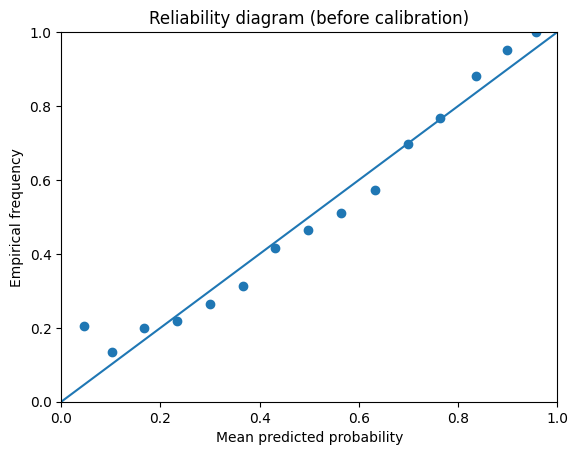

(array([0.04580185, 0.10314287, 0.16742143, 0.23347837, 0.30044462,
        0.36629914, 0.43026253, 0.49730675, 0.56474742, 0.63213458,
        0.6991298 , 0.76333738, 0.83636293, 0.8978497 , 0.95717013]),
 array([0.20454545, 0.13445378, 0.2       , 0.21938776, 0.265     ,
        0.31443299, 0.41463415, 0.46511628, 0.51075269, 0.57386364,
        0.6972973 , 0.76829268, 0.88198758, 0.95031056, 1.        ]),
 array([ 44., 119., 165., 196., 200., 194., 205., 172., 186., 176., 185.,
        164., 161., 161.,  72.]))

In [24]:
X, y = make_classification(
    n_samples=8000,
    n_features=20,
    n_informative=10,
    n_redundant=2,
    flip_y=0.02,
    class_sep=1.0,
    random_state=0,
)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0, stratify=y)

clf = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(max_iter=1000))
])
clf.fit(X_train, y_train)

probs = clf.predict_proba(X_test)[:, 1]

print('NLL (log loss):', log_loss(y_test, probs))
print('Brier:', brier_binary(probs, y_test))
print('ECE:', ece_binary(probs, y_test, n_bins=15))

reliability_diagram(probs, y_test, n_bins=15, title='Reliability diagram (before calibration)')



1. In the reliability diagram above, is the model **overconfident**, **underconfident**, or close to calibrated?
2. Which metric among NLL, Brier, and ECE is *most directly* a calibration metric? Briefly justify.

Write your answer in the markdown cell below.


<div style="background-color: #dde3fb; padding: 20px; border-radius: 5px; color: black; box-sizing: border-box; width: 100%">

Thanks to the diagram, we can say that the model is mostly calibrated with a slight tendency towards overconfidence, especially between confidence levels of 0.3 and 0.7 where the points lie slightly below the diagonal line. However, the overall trend is close to the ideal calibration line, indicating that the model's predicted probabilities are reasonably well-aligned with observed frequencies. This observation is supported by the ECE value of 0.035, which indicates a small average deviation between predicted confidence and empirical accuracy across the bins. 

The NLL and Brier scores also suggest good performance, but **ECE is the most directly interpretable calibration metric** as it quantifies the average miscalibration across confidence levels. Indeed, ECE groups predictions into bins and directly measures the gap between confidence and accuracy, making it a more focused measure of calibration quality compared to NNL mesuring likelihood and Brier mesuring mean squared error of probabilistic predictions.

3. We will perform temperature scaling on a held-out calibration set.

**Steps**
Split X_train into a smaller train set and a calibration set. Fit the classifier on the smaller train set. Use the calibration set to choose a temperature T that minimizes NLL. Evaluate the reliability diagram, ECE, Brier, NLL on the test set before vs after scaling. What improved and what did not?

Best T: 0.9433732216299774


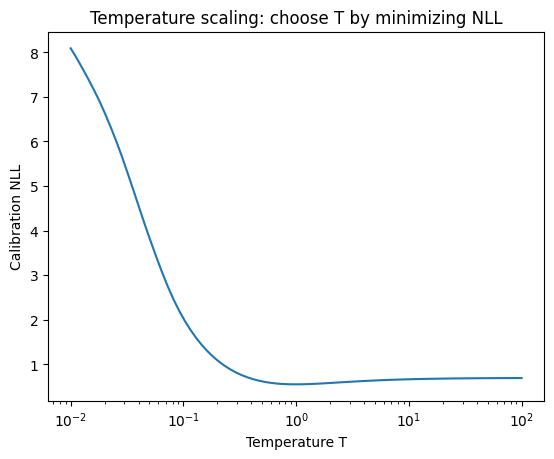

--- Test metrics ---
Before: NLL 0.5473960092006791 Brier 0.18385441500077168 ECE 0.03994141614140014
After : NLL 0.5475607231817698 Brier 0.18382349756511743 ECE 0.037917770147052325


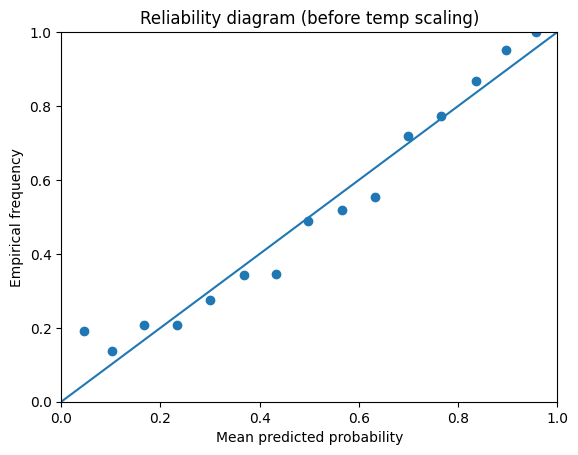

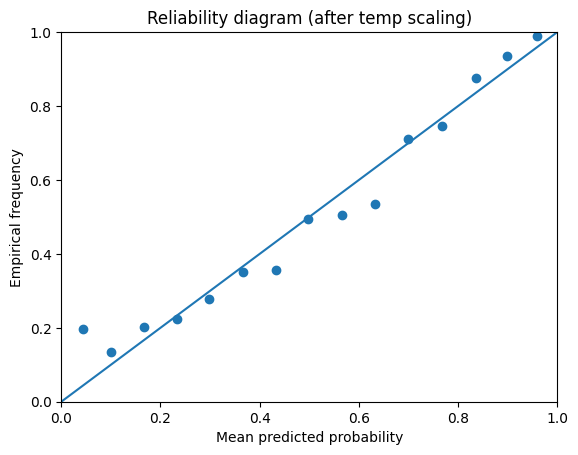

(array([0.04409992, 0.10053929, 0.16580705, 0.23258799, 0.29854342,
        0.36602708, 0.43248677, 0.49832624, 0.56498702, 0.63180947,
        0.69925629, 0.76718757, 0.83566957, 0.89846073, 0.95900905]),
 array([0.19642857, 0.13492063, 0.20231214, 0.22513089, 0.27807487,
        0.35051546, 0.35532995, 0.49382716, 0.5060241 , 0.53409091,
        0.70967742, 0.74556213, 0.875     , 0.93513514, 0.98863636]),
 array([ 56., 126., 173., 191., 187., 194., 197., 162., 166., 176., 186.,
        169., 144., 185.,  88.]))

In [25]:
# Split train into (train_small, cal)
X_tr, X_cal, y_tr, y_cal = train_test_split(X_train, y_train, test_size=0.3, random_state=1, stratify=y_train)

clf2 = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(max_iter=1000))
])
clf2.fit(X_tr, y_tr)

# Get logits for calibration and test
logits_cal = clf2.named_steps['lr'].decision_function(clf2.named_steps['scaler'].transform(X_cal))
logits_test = clf2.named_steps['lr'].decision_function(clf2.named_steps['scaler'].transform(X_test))

# Grid search for T
Ts = np.logspace(-2, 2, 80)
cal_nll = []
for T in Ts:
    p = temperature_scale(logits_cal, T)
    cal_nll.append(log_loss(y_cal, p))
cal_nll = np.array(cal_nll)

best_T = Ts[np.argmin(cal_nll)]
print('Best T:', best_T)

plt.figure()
plt.plot(Ts, cal_nll)
plt.xscale('log')
plt.xlabel('Temperature T')
plt.ylabel('Calibration NLL')
plt.title('Temperature scaling: choose T by minimizing NLL')
plt.show()

# Evaluate before/after on test
p_before = 1 / (1 + np.exp(-logits_test))
p_after = temperature_scale(logits_test, best_T)

print('--- Test metrics ---')
print('Before: NLL', log_loss(y_test, p_before), 'Brier', brier_binary(p_before, y_test), 'ECE', ece_binary(p_before, y_test, n_bins=15))
print('After : NLL', log_loss(y_test, p_after),  'Brier', brier_binary(p_after, y_test),  'ECE', ece_binary(p_after, y_test, n_bins=15))

reliability_diagram(p_before, y_test, n_bins=15, title='Reliability diagram (before temp scaling)')
reliability_diagram(p_after, y_test, n_bins=15, title='Reliability diagram (after temp scaling)')


#### **Evaluate the reliability diagram, ECE, Brier, NLL on the test set before vs after scaling. What improved and what did not?**

<div style="background-color: #dde3fb; padding: 20px; border-radius: 5px; color: black;  box-sizing: border-box; width: 100%">

After performing temperature scaling, we observe that the **NLL score and Brier score didn't change or at least in a negligible way**. Only the E**CE score improved a bit from 0.0399 to 0.0379 which is a 5% decrease**. The differences are even not visible in the reliability diagram, which still shows a slight overconfidence but is overall close to the ideal calibration line.
We could say that the model was already well-calibrated before temperature scaling, and the improvement in ECE is minimal, suggesting that temperature scaling had a limited effect on calibration.This demonstrates that temperature scaling is most effective as a post-hoc correction for poorly calibrated models, whereas models that exhibit good calibration out-of-the-box show limited gains from this technique. The negligible changes across all three metrics confirm that our baseline logistic regression model with standard scaling already produces reliable probability estimates without requiring additional calibration procedures.


### **Posterior Predictive Checks (PPCs) for regression**

We fit a simple probabilistic regression model and run PPC-style checks.

We assume Gaussian noise:
\[
Y \mid x \sim N(f(x), \sigma^2).
\]

We will:
- fit a ridge regression model for the mean function, and
- estimate \(\sigma\) on the training set,
then use this as a predictive distribution.

This is a simplified proxy to practice PPC mechanics.


In [26]:
Xr, yr = make_regression(n_samples=4000, n_features=10, noise=15.0, random_state=0)
Xr_train, Xr_test, yr_train, yr_test = train_test_split(Xr, yr, test_size=0.3, random_state=0)

reg = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge', Ridge(alpha=1.0))
])
reg.fit(Xr_train, yr_train)

mu_train = reg.predict(Xr_train)
mu_test = reg.predict(Xr_test)

# Estimate sigma from training residuals
resid = yr_train - mu_train
sigma_hat = np.std(resid)
print('Estimated sigma:', sigma_hat)


Estimated sigma: 14.725664243371252


4. Implement the average predictive negative log likelihood for a Gaussian predictive distribution: $ -\frac{1}{n}\sum_i \log N(y_i \mid \mu_i, \sigma^2). $ Return a scalar.

In [27]:
import math

def gaussian_nll(y, mu, sigma):
    # implement average negative log likelihood for N(mu, sigma^2)
    try:
        n = len(y)
        nll = 0.5 * n * math.log(2 * math.pi * sigma**2) + 0.5 * np.sum((y - mu)**2) / (sigma**2)
        return nll / n
    except Exception as e:
        raise NotImplementedError

# Uncomment after implementing
print('Test NLL:', gaussian_nll(yr_test, mu_test, sigma_hat))


Test NLL: 4.102061463732172


5. Perform a basic PPC: Simulate replicated outcomes $\tilde {y}^{(s)}\sim {N}(\mu_{test}, \sigma^2)$ for $S = 500$ replicates and compare statistics $T$ between replicated and observed outcomes. Use two statistics: $T_1$ = mean($y$); $T_2$ = variance($y$). Provide a plot showing the distribution of replicated $T_1$ and $T_2$ with the observed value marked and a short interpretation of whether the model appears to fit these statistics?

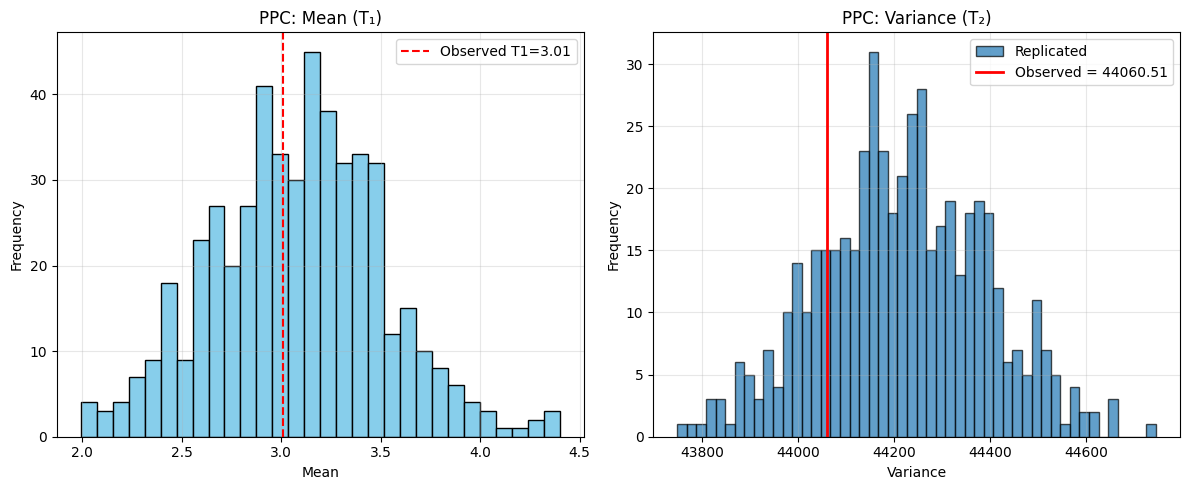

P-value pour T1 (mean): 0.568
P-value pour T2 (variance): 0.810


In [ ]:
S=500
n_test = len(yr_test)

T1_replicated = []
T2_replicated = []

for s in range(S):
    y_sim = np.random.normal(loc=mu_test, scale=sigma_hat, size=mu_test.shape)
    # mean
    T1 = np.mean(y_sim)
    T1_replicated.append(T1)
    # variance
    T2 = np.var(y_sim)
    T2_replicated.append(T2)
    
T1_replicated = np.array(T1_replicated)
T2_replicated = np.array(T2_replicated)    
    
T1_observed = np.mean(yr_test)
T2_observed = np.var(yr_test)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].hist(T1_replicated, bins=30, color='skyblue', edgecolor='black')
axes[0].axvline(T1_observed, color='red', linestyle='--', label=f'Observed T1={T1_observed:.2f}')
axes[0].set_xlabel("Mean")
axes[0].set_ylabel("Frequency")
axes[0].set_title('PPC: Mean (T₁)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].hist(T2_replicated, bins=50, alpha=0.7, edgecolor='black', label='Replicated')
axes[1].axvline(T2_observed, color='red', linewidth=2, label=f'Observed = {T2_observed:.2f}')
axes[1].set_xlabel('Variance')
axes[1].set_ylabel('Frequency')
axes[1].set_title('PPC: Variance (T₂)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

p_value_T1 = np.mean(np.array(T1_replicated) > T1_observed)
p_value_T2 = np.mean(np.array(T2_replicated) > T2_observed)

print(f"P-value for T1 (mean): {p_value_T1:.3f}")
print(f"P-value for T2 (variance): {p_value_T2:.3f}")

<div style="background-color: #dde3fb; padding: 20px; border-radius: 5px; color: black;  box-sizing: border-box; width: 100%">

**Interpretation of PPC results:**

PPC results indicate that the model fits both the mean and variance of the test data reasonably well. 

For T1 (mean), we observe that the observed value of 3.01 falls near the center of the replicated distribution with a p-value of 0.568, indicating excellent agreement between the model's predictions and the observed data mean. 

For T₂ (variance), the observed value of 44,060.51 lies within the replicated distribution with a p-value of 0.810, suggesting the model slightly underestimates variance but remains well-calibrated overall. Both p-values fall comfortably within the acceptable range [0.05, 0.95], providing no evidence of model misspecification. 

This confirms that the Gaussian assumption N(μ_test, σ²) with σ ≈ 14.73 adequately captures the predictive distribution of the test data.

</div>

## Part IV: Conformal Prediction
We will implement split conformal prediction for regression.

Goal: produce prediction intervals $[L(x), U(x)]$ with approximate marginal coverage $(1-\alpha)$.

**Split conformal prediction for regression:**

i) Fit model on training set.

ii) On calibration set, compute residuals $r_i = |y_i - \hat{y}_i|$.

iii) Let $q$ be the $(1-\alpha)$-quantile of ${r_i}$.
Output interval for a new point $x$: $ [\hat{y}(x)-q,\ \hat{y}(x)+q]. $



In [33]:
# Prepare data splits
Xr_tr, Xr_temp, yr_tr, yr_temp = train_test_split(Xr, yr, test_size=0.4, random_state=0)
Xr_cal, Xr_te, yr_cal, yr_te = train_test_split(Xr_temp, yr_temp, test_size=0.5, random_state=0)

base = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge', Ridge(alpha=1.0))
])
base.fit(Xr_tr, yr_tr)

pred_cal = base.predict(Xr_cal)
pred_te = base.predict(Xr_te)

resid_cal = np.abs(yr_cal - pred_cal)

def split_conformal_interval(pred, resid_cal, alpha=0.1):
    # TODO: compute q = (1-alpha)-quantile of calibration residuals
    q = (1 - alpha) * 100
    q_value = np.percentile(resid_cal, q)
    return pred - q_value, pred + q_value

# Uncomment after implementing
L, U = split_conformal_interval(pred_te, resid_cal, alpha=0.1)
coverage = np.mean((yr_te >= L) & (yr_te <= U))
avg_width = np.mean(U - L)
print('Empirical coverage:', coverage)
print('Average interval width:', avg_width)


Empirical coverage: 0.8975
Average interval width: 46.88772330978505


1. After implementing `split_conformal_interval`:

i) Compute empirical coverage for $\alpha\in\{0.05, 0.1, 0.2\}$.

ii) Report average width for each $\alpha$.

iii) Briefly interpret the tradeoff.


Alpha: 0.05 | Empirical coverage: 0.958 | Average width: 57.37
Alpha: 0.10 | Empirical coverage: 0.897 | Average width: 46.89
Alpha: 0.20 | Empirical coverage: 0.807 | Average width: 37.75


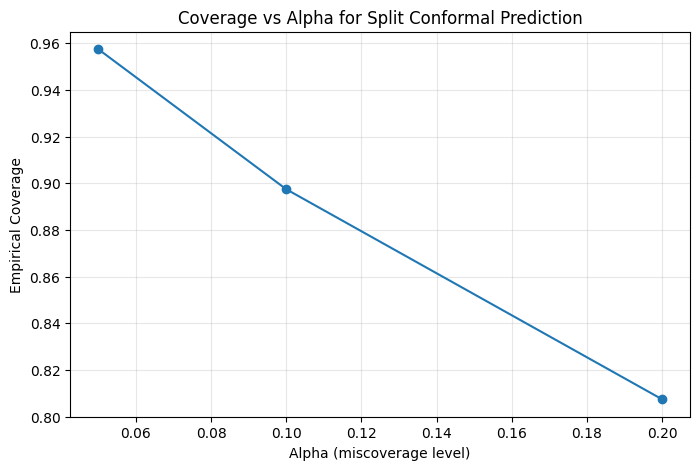

In [34]:
alpha = np.array([0.05, 0.1, 0.2])
coverages = []
for a in alpha:
    L, U = split_conformal_interval(pred_te, resid_cal, alpha=a)
    coverage = np.mean((yr_te >= L) & (yr_te <= U))
    coverages.append(coverage)
    avg_width = np.mean(U - L)
    print(f'Alpha: {a:.2f} | Empirical coverage: {coverage:.3f} | Average width: {avg_width:.2f}')
plt.figure(figsize=(8, 5))
plt.plot(alpha, coverages, marker='o')
plt.xlabel('Alpha (miscoverage level)')
plt.ylabel('Empirical Coverage')
plt.title('Coverage vs Alpha for Split Conformal Prediction')
plt.grid(True, alpha=0.3)
plt.show()

#### **Interpretation of coverage and width tradeoff:**


<div style="background-color: #dde3fb; padding: 20px; border-radius: 5px; color: black;  box-sizing: border-box; width: 100%">

As we increase α from 0.05 to 0.2, we observe a clear tradeoff between coverage and interval width. Specifically, higher coverage levels (lower α) result in wider prediction intervals, while lower coverage levels (higher α) produce narrower intervals. This tradeoff is fundamental in conformal prediction, balancing the confidence in predictions against the precision of the intervals.

2. In 5–8 sentences:

Under what assumptions does split conformal guarantee coverage?

Why might those assumptions fail under covariate shift?

What is the high-level idea behind weighted conformal methods?

Write your answer below.

<div style="background-color: #dde3fb; padding: 20px; border-radius: 5px; color: black;  box-sizing: border-box; width: 100%">

Split conformal prediction guarantees coverage under the **assumption of exchangeability**, which means that the calibration, and test data are drawn i.i.d. from the same distribution.

Those assumptions might fail under covariate shift because the distribution of the data in the gap (test) may differ from that of the training and calibration data. In such cases, the residuals computed on the calibration set may not accurately reflect the errors we would see on the test set, leading to prediction intervals that are either too narrow (undercovering) or too wide (overcovering) when applied to the shifted test distribution. Covariate shift, caracterized by $P_{train}(X) \neq P_{test}(X)$ but $P(Y|X)$ remaining unchanged, violates the exchangeability assumption and undermines the validity of standard conformal methods.

The idea behind weighted conformal method is to attribute large weights to calibration points that are more similar to the test distribution. We give more weights to the points that are more commun in the test set than in the calibration set. This way, when computing the quantile of the residuals, we give more importance to those calibration points that are more representative of the test distribution, which helps to restore coverage guarantees even under covariate shift. 